# Tarea 3: Metodología de Modelamiento
## Laboratorio 1 – Predicción y Clasificación en la Industria Azucarera
### Ingenio Providencia | Algoritmos y Programación III | ICESI 2026

---
**Estructura:**
- **Sección 1** – Regresión: TCH y %Sac.Caña (OLS · Ridge · Random Forest · XGBoost)
- **Sección 2** – Clasificación: nivel_TCH y nivel_sacarosa (Logística · KNN · RF · XGBoost)
- Validación rigurosa: hold-out 80/20 + k-fold CV (k=5)

---
## 0. Configuración e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats

# Sklearn – preprocesamiento, validación y métricas
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 11})
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga y Preparación de Datos

In [2]:
df_reg = pd.read_csv('dataset_regresion_procesado.csv')
df_clf = pd.read_csv('dataset_clasificacion_procesado.csv')

print(f'Regresión  : {df_reg.shape}')
print(f'Clasificación: {df_clf.shape}')
print(f'\nColumnas regresión  : {df_reg.columns.tolist()}')
print(f'\nColumnas clasificación: {df_clf.columns.tolist()}')

Regresión  : (20559, 28)
Clasificación: (2187, 22)

Columnas regresión  : ['Edad Ult Cos', 'Variedad', 'Suelo', 'Zona', 'Tenencia', 'Vejez', 'Destino 1=Semilla', 'Cod. T.Cultivo', 'Dist Km', 'Tipo Quema', 'T.Corte', 'Dosis Madurante', 'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', 'M3 Riego', 'DDUlt.Riego', 'Período', 'TCH', '%Sac.Caña', 'Variedad_cod', 'Suelo_cod', 'Zona_cod', 'Tipo Quema_cod', 'T.Corte_cod']

Columnas clasificación: ['variedad', 'edad', 'cortes', 'lluvias', 'grupo_tenencia', 'pct_diatrea', 'tipocorte', 'madurada', 'dosismad', 'semsmad', 'vejez', 'mes', 'me', 'TCH', 'sacarosa', 'nivel_TCH', 'nivel_sacarosa', 'variedad_cod', 'tipocorte_cod', 'madurada_cod', 'nivel_TCH_num', 'nivel_sacarosa_num']


In [3]:
# ── REGRESIÓN ────────────────────────────────────────────────────────────
# Variables NUMÉRICAS (se escalan para modelos lineales/KNN; pasan crudas a árboles).
NUM_REG = [
    'Edad Ult Cos', 'Vejez', 'Destino 1=Semilla', 'Cod. T.Cultivo',
    'Dist Km', 'Dosis Madurante', 'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo',
    'M3 Riego', 'DDUlt.Riego', 'Tenencia', 'Período',
]
# Variables CATEGÓRICAS (One-Hot Encoding via ColumnTransformer).
# Decisión clave: NO usar LabelEncoder con modelos lineales — introduce un orden
# artificial entre categorías nominales (ej. "Variedad cod 8 > Variedad cod 3"),
# lo que invalida la interpretación de coeficientes.
CAT_REG = ['Variedad', 'Suelo', 'Zona', 'Tipo Quema', 'T.Corte']

# Lluvias por sub-periodo: excluidas en lineales (colinealidad perfecta con Lluvias Ciclo)
# pero incluidas en árboles (capturan patrones temporales no lineales).
NUM_REG_TREE_EXTRA = [
    'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC'
]
NUM_REG_TREE = NUM_REG + NUM_REG_TREE_EXTRA
TARGETS_REG  = ['TCH', '%Sac.Caña']

# ── CLASIFICACIÓN ─────────────────────────────────────────────────────────
# HALLAZGO: BD_IPSA_1940 es un subconjunto donde 'variedad', 'tipocorte' y 'madurada'
# son CONSTANTES (CC01-1940 / Mecanizado Verde / SI). Cero varianza → cero información.
# Las descartamos. 'grupo_tenencia' es categórica con 3 niveles (1,2,3) y ya está
# numéricamente codificada; la dejamos como numérica.
NUM_CLF = [
    'edad', 'cortes', 'lluvias', 'grupo_tenencia', 'pct_diatrea',
    'dosismad', 'semsmad', 'vejez', 'mes', 'me'
]
CAT_CLF = []  # No hay categóricas con información tras el filtro

TARGETS_CLF = ['nivel_TCH_num', 'nivel_sacarosa_num']
LABELS_CLF  = ['Bajo', 'Medio', 'Alto']

print(f'Regresión   – numéricas: {len(NUM_REG)}, categóricas: {len(CAT_REG)}')
print(f'  + lluvias por sub-periodo (solo árboles): {len(NUM_REG_TREE_EXTRA)}')
print(f'Clasificación – numéricas: {len(NUM_CLF)}, categóricas: {len(CAT_CLF)}')
print(f'  Descartadas por ser constantes: variedad, tipocorte, madurada')

Regresión   – numéricas: 12, categóricas: 5
  + lluvias por sub-periodo (solo árboles): 4
Clasificación – numéricas: 10, categóricas: 0
  Descartadas por ser constantes: variedad, tipocorte, madurada


---
# SECCIÓN 1 – REGRESIÓN
## 2. División Train / Test (80 / 20)

In [4]:
# Split 80/20 estratificado por cuartiles de TCH (asegura distribución similar de y
# en train y test para modelos no-lineales sensibles a outliers).
y_strat_reg = pd.qcut(df_reg['TCH'], q=4, labels=False, duplicates='drop')
idx = np.arange(len(df_reg))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=SEED, stratify=y_strat_reg
)

# DataFrames de features (mantener nombres para que ColumnTransformer funcione)
X_reg_lin_full  = df_reg[NUM_REG + CAT_REG]
X_reg_tree_full = df_reg[NUM_REG_TREE + CAT_REG]

X_reg_lin_train,  X_reg_lin_test  = X_reg_lin_full.iloc[idx_train],  X_reg_lin_full.iloc[idx_test]
X_reg_tree_train, X_reg_tree_test = X_reg_tree_full.iloc[idx_train], X_reg_tree_full.iloc[idx_test]

Y = {t: df_reg[t].values for t in TARGETS_REG}

# Preprocesador LINEALES (OLS / Ridge): StandardScaler para numéricas + OHE para categóricas.
# IMPORTANTE: drop='first' evita la 'dummy variable trap' — sin esto, las dummies de cada
# variable categórica suman 1 y, junto con el intercepto, vuelven la matriz singular
# (rompe el OLS). min_frequency=0.005 agrupa categorías raras en 'infrequent'.
prep_lin = ColumnTransformer([
    ('num', StandardScaler(), NUM_REG),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=0.005,
                           sparse_output=False, drop='first'), CAT_REG)
])

# Preprocesador ÁRBOLES (RF / XGBoost): no necesitan escalado ni evitar la dummy trap.
prep_tree = ColumnTransformer([
    ('num', 'passthrough', NUM_REG_TREE),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=0.005, sparse_output=False), CAT_REG)
])

print(f'Train: {len(idx_train):,} | Test: {len(idx_test):,}')
for t in TARGETS_REG:
    print(f'  {t} → train media={Y[t][idx_train].mean():.2f} | test media={Y[t][idx_test].mean():.2f}')

# Verificar dimensiones tras OHE
n_lin  = prep_lin.fit(X_reg_lin_train).transform(X_reg_lin_train).shape[1]
n_tree = prep_tree.fit(X_reg_tree_train).transform(X_reg_tree_train).shape[1]
print(f'\nDimensiones tras preprocesamiento:')
print(f'  Lineal (con drop=first): {n_lin} columnas')
print(f'  Árbol  (sin drop)      : {n_tree} columnas')


Train: 16,447 | Test: 4,112
  TCH → train media=129.94 | test media=130.08
  %Sac.Caña → train media=12.32 | test media=12.32



Dimensiones tras preprocesamiento:
  Lineal (con drop=first): 70 columnas
  Árbol  (sin drop)      : 79 columnas


---
## 3. Modelo Benchmark – OLS (statsmodels)

Usamos **statsmodels** para obtener p-values, coeficientes e intervalos de confianza. 
La regresión lineal es el baseline interpretable que todo modelo avanzado debe superar.

In [5]:
# OLS con OHE correcto + validación cruzada (5-fold) + diagnóstico de coeficientes.
# La consigna pide CV en TODOS los modelos: aquí lo hacemos para el OLS también.
resultados_ols = {}

for target in TARGETS_REG:
    y_train = Y[target][idx_train]
    y_test  = Y[target][idx_test]

    # 1) CV con sklearn LinearRegression (5-fold sobre el set de entrenamiento)
    pipe_lr = Pipeline([('prep', prep_lin), ('lr', LinearRegression())])
    cv = cross_validate(
        pipe_lr, X_reg_lin_train, y_train, cv=5,
        scoring={'r2': 'r2',
                 'neg_rmse': 'neg_root_mean_squared_error',
                 'neg_mae': 'neg_mean_absolute_error'},
        n_jobs=-1
    )
    cv_r2   = cv['test_r2'].mean()
    cv_rmse = -cv['test_neg_rmse'].mean()
    cv_mae  = -cv['test_neg_mae'].mean()

    # 2) OLS final con statsmodels para coeficientes / p-values / IC
    Xt_train = prep_lin.fit_transform(X_reg_lin_train)
    Xt_test  = prep_lin.transform(X_reg_lin_test)
    feat_names = list(prep_lin.get_feature_names_out())

    Xt_train_const = sm.add_constant(Xt_train, has_constant='add')
    Xt_test_const  = sm.add_constant(Xt_test,  has_constant='add')
    modelo = sm.OLS(y_train, Xt_train_const).fit()
    y_pred = modelo.predict(Xt_test_const)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    resultados_ols[target] = {
        'modelo': modelo, 'y_test': y_test, 'y_pred': y_pred,
        'feat_names': feat_names,
        'R2': r2, 'RMSE': rmse, 'MAE': mae,
        'cv_r2': cv_r2, 'cv_rmse': cv_rmse, 'cv_mae': cv_mae
    }

    print(f"\n{'='*60}")
    print(f' OLS – {target}')
    print(f"{'='*60}")
    print(f'  CV (5-fold)   : R²={cv_r2:.4f}  RMSE={cv_rmse:.4f}  MAE={cv_mae:.4f}')
    print(f'  Test (hold-o.): R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')
    print(f'  R² ajust train: {modelo.rsquared_adj:.4f}')

    # Top coeficientes significativos
    params  = np.asarray(modelo.params)[1:]
    pvalues = np.asarray(modelo.pvalues)[1:]
    coef_df = pd.DataFrame({
        'Feature': feat_names, 'Coef': params, 'P-value': pvalues
    }).assign(abs_coef=lambda d: d['Coef'].abs())
    sig = coef_df[coef_df['P-value'] < 0.05].sort_values('abs_coef', ascending=False)
    print(f'\n  Variables significativas (p<0.05): {len(sig)}/{len(feat_names)}')
    print(sig[['Feature', 'Coef', 'P-value']].head(10).to_string(index=False))


 OLS – TCH
  CV (5-fold)   : R²=0.3147  RMSE=26.6713  MAE=20.4953
  Test (hold-o.): R²=0.3203  RMSE=26.9717  MAE=20.6633
  R² ajust train: 0.3200

  Variables significativas (p<0.05): 54/70
                Feature       Coef      P-value
 cat__Variedad_CC09-066  43.723212 1.676243e-36
       cat__Suelo_YUMBO  40.812751 1.571049e-32
 cat__Variedad_CC05-430  39.179028 2.329695e-67
  cat__Suelo_PALMIRITA   26.617764 7.697060e-15
 cat__Variedad_CC04-195  26.247541 3.726269e-14
 cat__Variedad_CC09-535  20.858804 5.488509e-11
     cat__Suelo_JAMAICA  20.526970 2.047879e-10
cat__Variedad_CC01-1940  20.040917 2.595443e-20
  cat__Suelo_SANTA ROSA  19.392198 2.207217e-14
    cat__Suelo_CERRITO  -18.761614 1.253949e-15



 OLS – %Sac.Caña
  CV (5-fold)   : R²=0.2632  RMSE=0.9763  MAE=0.7606
  Test (hold-o.): R²=0.2651  RMSE=0.9830  MAE=0.7666
  R² ajust train: 0.2683

  Variables significativas (p<0.05): 31/70
                     Feature      Coef      P-value
     cat__Variedad_CC93-4181  0.991835 2.048802e-19
cat__Zona_infrequent_sklearn -0.692521 2.606525e-02
     cat__Variedad_CC93-4418  0.614936 3.850861e-13
       cat__Variedad_CC85-92  0.545512 1.315983e-11
     cat__Variedad_RB73-2223 -0.449927 2.183422e-07
            cat__Suelo_YUMBO -0.392383 1.777749e-03
cat__Tipo Quema_Q.PROGRAMADA  0.369589 2.108379e-06
      cat__Variedad_CC04-195 -0.347214 6.193021e-03
       cat__Variedad_CC98-72  0.340801 3.076156e-03
         cat__Suelo_CERRITO   0.331880 1.098252e-04


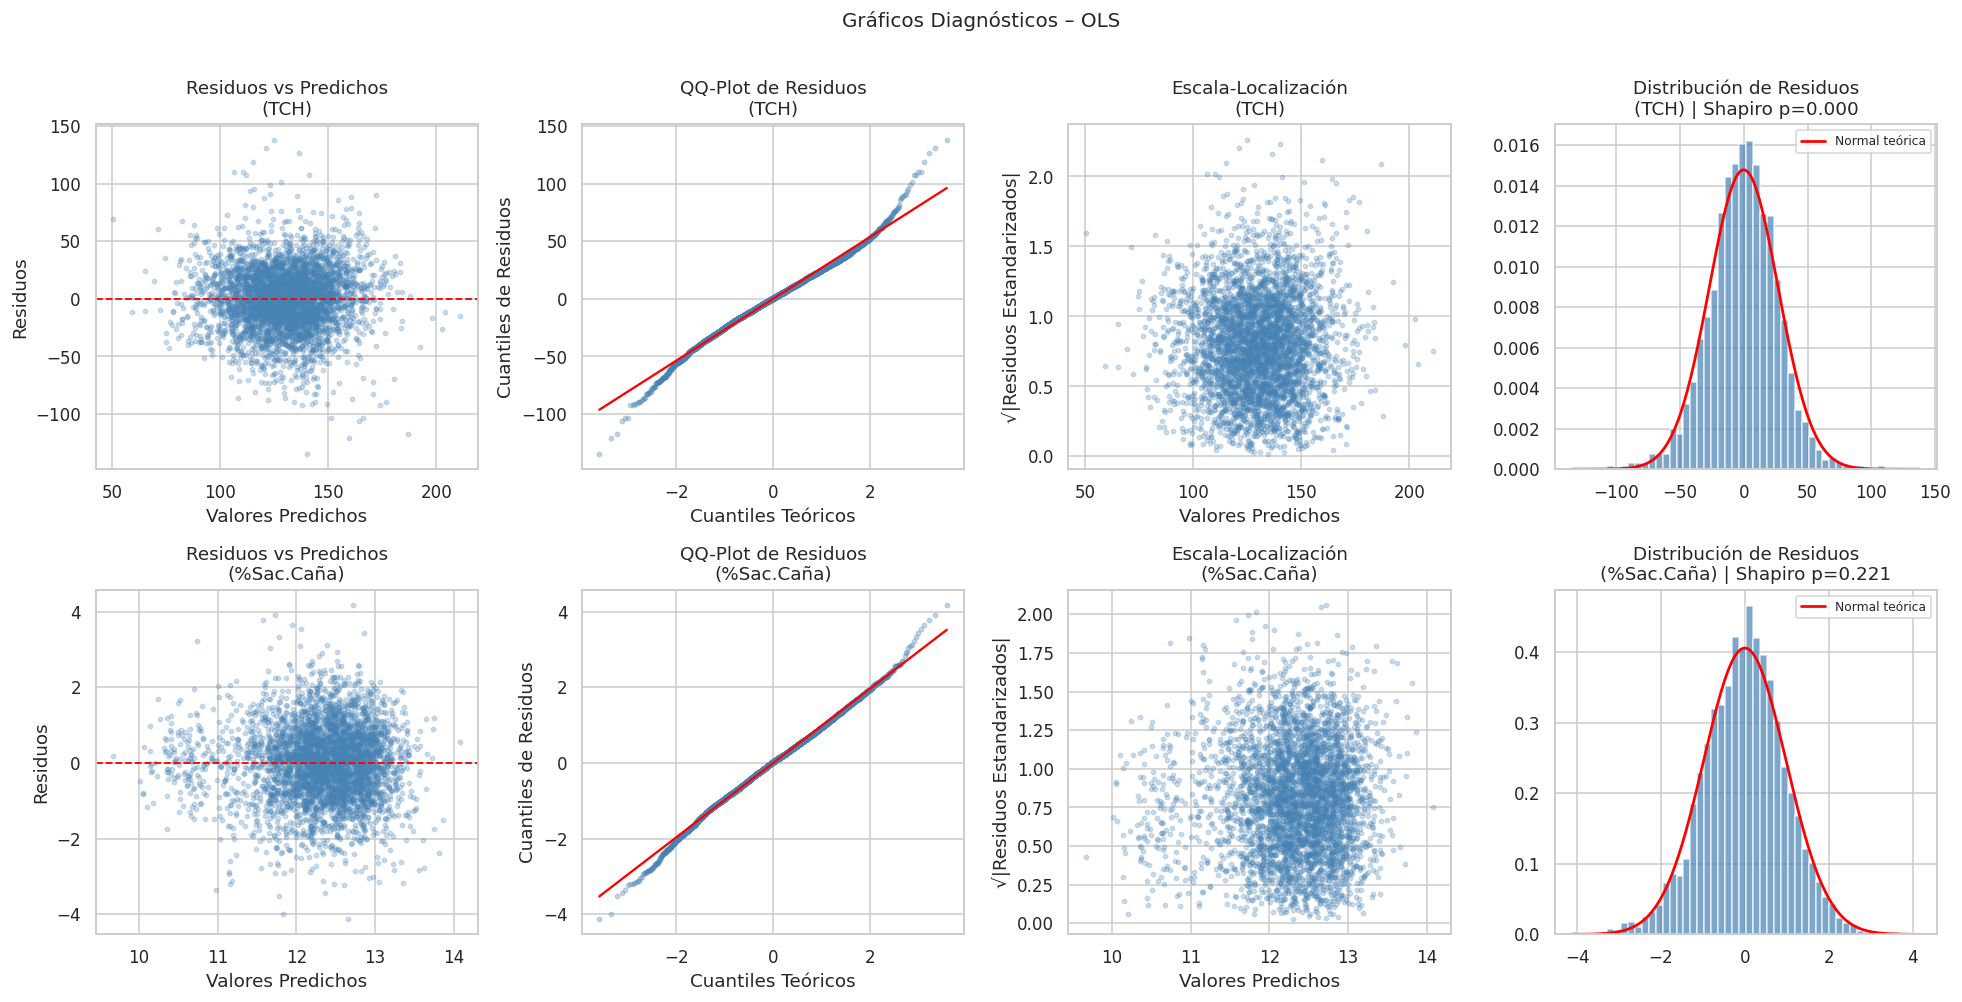

In [6]:
# Gráficos diagnósticos del modelo OLS
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row, target in enumerate(TARGETS_REG):
    res = resultados_ols[target]
    modelo = res['modelo']
    y_test  = res['y_test']
    y_pred  = res['y_pred']
    residuos = y_test - y_pred

    # 1. Residuos vs Valores Ajustados (homocedasticidad)
    ax = axes[row, 0]
    ax.scatter(y_pred, residuos, alpha=0.25, s=8, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Valores Predichos')
    ax.set_ylabel('Residuos')
    ax.set_title(f'Residuos vs Predichos\n({target})')

    # 2. QQ-Plot (normalidad de residuos)
    ax = axes[row, 1]
    (osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=8, color='steelblue')
    ax.plot(osm, slope*np.array(osm) + intercept, color='red', linewidth=1.5)
    ax.set_xlabel('Cuantiles Teóricos')
    ax.set_ylabel('Cuantiles de Residuos')
    ax.set_title(f'QQ-Plot de Residuos\n({target})')

    # 3. Escala-Localización (raíz de residuos estandarizados)
    ax = axes[row, 2]
    std_res = np.sqrt(np.abs(residuos / (residuos.std() + 1e-8)))
    ax.scatter(y_pred, std_res, alpha=0.25, s=8, color='steelblue')
    ax.set_xlabel('Valores Predichos')
    ax.set_ylabel('√|Residuos Estandarizados|')
    ax.set_title(f'Escala-Localización\n({target})')

    # 4. Histograma de residuos
    ax = axes[row, 3]
    ax.hist(residuos, bins=50, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    xr = np.linspace(residuos.min(), residuos.max(), 200)
    ax.plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
            color='red', linewidth=1.8, label='Normal teórica')
    stat_sw, p_sw = stats.shapiro(residuos[:500])  # shapiro con muestra
    ax.set_title(f'Distribución de Residuos\n({target}) | Shapiro p={p_sw:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Gráficos Diagnósticos – OLS', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

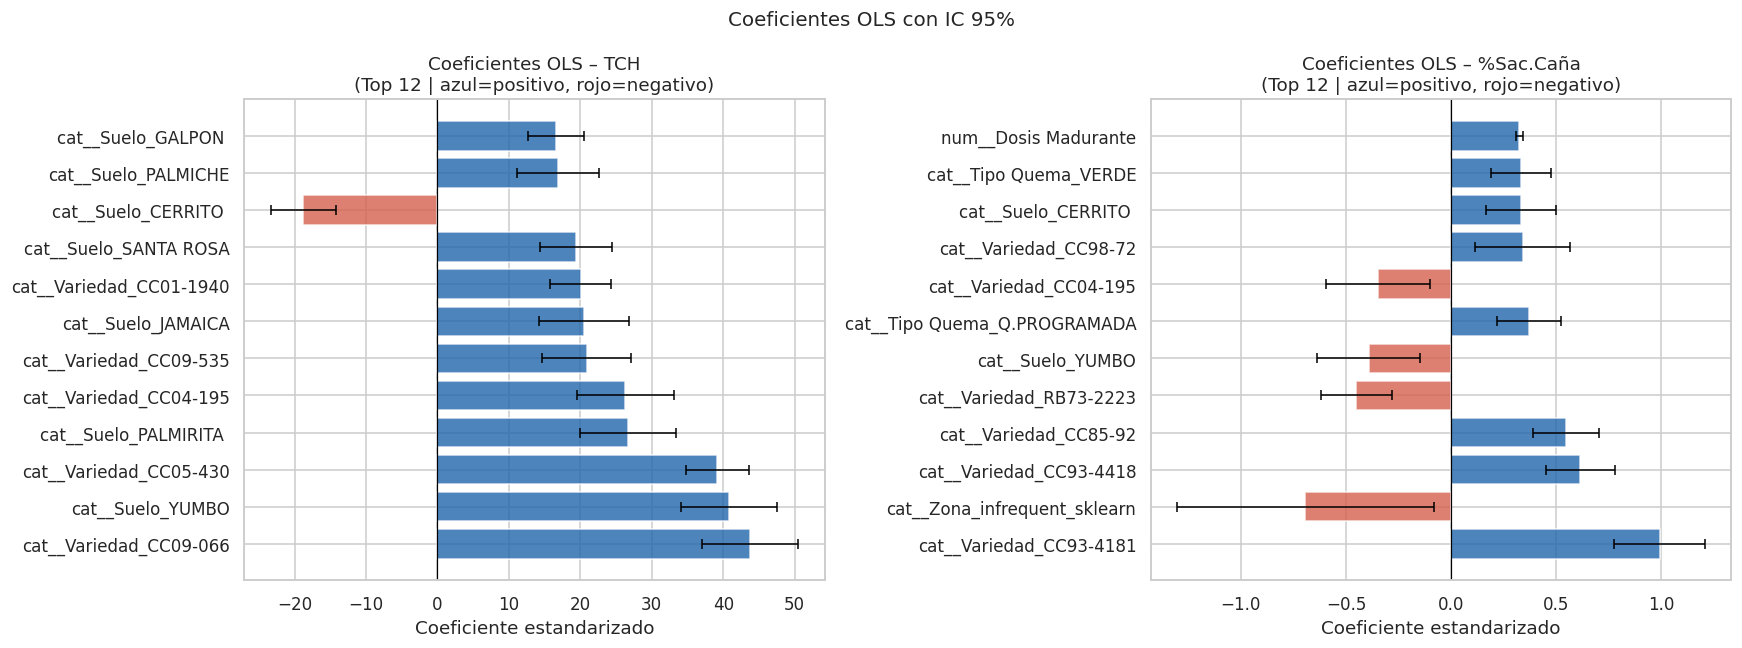

In [7]:
# Top 12 coeficientes OLS por magnitud absoluta (con IC 95% y signo).
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target in zip(axes, TARGETS_REG):
    res = resultados_ols[target]
    modelo = res['modelo']
    feat_names = res['feat_names']
    params  = np.asarray(modelo.params)
    pvalues = np.asarray(modelo.pvalues)
    ci      = np.asarray(modelo.conf_int())

    coef_df = pd.DataFrame({
        'Feature': feat_names,
        'Coef':    params[1:],
        'CI_low':  ci[1:, 0],
        'CI_high': ci[1:, 1],
        'P-value': pvalues[1:]
    }).assign(abs_coef=lambda d: d['Coef'].abs())

    top = coef_df.nlargest(12, 'abs_coef')
    colors = ['#2166ac' if v > 0 else '#d6604d' for v in top['Coef']]
    ax.barh(top['Feature'], top['Coef'], color=colors, alpha=0.8, edgecolor='white')
    ax.errorbar(top['Coef'], top['Feature'],
                xerr=[top['Coef'] - top['CI_low'], top['CI_high'] - top['Coef']],
                fmt='none', color='black', capsize=3, linewidth=1)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coeficientes OLS – {target}\n(Top 12 | azul=positivo, rojo=negativo)')
    ax.set_xlabel('Coeficiente estandarizado')

plt.suptitle('Coeficientes OLS con IC 95%', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Modelo Benchmark – Ridge Regression

Ridge agrega penalización L2 a OLS: ideal para manejar la multicolinealidad residual. 
Sintonizamos `alpha` con 5-fold CV sobre el conjunto de entrenamiento.

In [8]:
# Ridge dentro de un Pipeline (preprocesador OHE + Ridge). GridSearch sobre alpha.
resultados_ridge = {}

alphas = [0.01, 0.1, 1, 10, 50, 100, 500]

for target in TARGETS_REG:
    y_train = Y[target][idx_train]
    y_test  = Y[target][idx_test]

    pipe = Pipeline([('prep', prep_lin), ('ridge', Ridge(random_state=SEED))])
    gs = GridSearchCV(
        pipe, {'ridge__alpha': alphas},
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    gs.fit(X_reg_lin_train, y_train)
    best = gs.best_estimator_
    y_pred = best.predict(X_reg_lin_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv_rmse = -gs.best_score_

    resultados_ridge[target] = {
        'modelo': best, 'y_test': y_test, 'y_pred': y_pred,
        'R2': r2, 'RMSE': rmse, 'MAE': mae,
        'best_alpha': gs.best_params_['ridge__alpha'], 'cv_rmse': cv_rmse
    }

    print(f'Ridge – {target}')
    print(f'  α óptimo (5-fold CV): {gs.best_params_["ridge__alpha"]}')
    print(f'  RMSE CV (train): {cv_rmse:.4f}')
    print(f'  R²  (test): {r2:.4f}  |  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}\n')

Ridge – TCH
  α óptimo (5-fold CV): 1
  RMSE CV (train): 26.6699
  R²  (test): 0.3202  |  RMSE: 26.9741  |  MAE: 20.6667



Ridge – %Sac.Caña
  α óptimo (5-fold CV): 10
  RMSE CV (train): 0.9758
  R²  (test): 0.2647  |  RMSE: 0.9833  |  MAE: 0.7666



---
## 5. Modelo Avanzado – Random Forest Regressor

Ensemble de árboles que captura **relaciones no lineales** e **interacciones** entre variables (ej. lluvias × variedad × edad). Robusto a outliers y multicolinealidad.

In [9]:
# Random Forest dentro de un Pipeline (preprocesador OHE + RF).
resultados_rf_reg = {}

# n_jobs=2 (control de memoria), n_iter=10, n_estimators ≤ 200.
param_dist_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 15, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [2, 4],
    'rf__max_features': ['sqrt', 0.5]
}

for target in TARGETS_REG:
    y_train = Y[target][idx_train]
    y_test  = Y[target][idx_test]

    pipe = Pipeline([
        ('prep', prep_tree),
        ('rf',   RandomForestRegressor(random_state=SEED, n_jobs=2))
    ])

    rs = RandomizedSearchCV(
        pipe, param_dist_rf, n_iter=10, cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=SEED, n_jobs=2
    )
    rs.fit(X_reg_tree_train, y_train)
    best = rs.best_estimator_
    y_pred = best.predict(X_reg_tree_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv_rmse = -rs.best_score_

    resultados_rf_reg[target] = {
        'modelo': best, 'y_test': y_test, 'y_pred': y_pred,
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'cv_rmse': cv_rmse,
        'best_params': rs.best_params_
    }

    print(f'RF Regressor – {target}')
    print(f'  Mejores parámetros: {rs.best_params_}')
    print(f'  RMSE CV (train): {cv_rmse:.4f}')
    print(f'  R²: {r2:.4f}  |  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}\n')


RF Regressor – TCH
  Mejores parámetros: {'rf__n_estimators': 100, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 20}
  RMSE CV (train): 23.3378
  R²: 0.4815  |  RMSE: 23.5571  |  MAE: 17.4119



RF Regressor – %Sac.Caña
  Mejores parámetros: {'rf__n_estimators': 100, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 20}
  RMSE CV (train): 0.8299
  R²: 0.4881  |  RMSE: 0.8204  |  MAE: 0.6278



---
## 6. Modelo Avanzado – XGBoost Regressor

Gradient boosting secuencial que minimiza el error residual de cada iteración. Suele liderar en datos tabulares con relaciones complejas.

In [10]:
# XGBoost dentro de un Pipeline (preprocesador OHE + XGBoost).
resultados_xgb_reg = {}

param_grid_xgb = {
    'xgb__n_estimators': [200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

for target in TARGETS_REG:
    y_train = Y[target][idx_train]
    y_test  = Y[target][idx_test]

    pipe = Pipeline([
        ('prep', prep_tree),
        ('xgb',  XGBRegressor(random_state=SEED, verbosity=0, n_jobs=2))
    ])

    rs = RandomizedSearchCV(
        pipe, param_grid_xgb, n_iter=12, cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=SEED, n_jobs=2
    )
    rs.fit(X_reg_tree_train, y_train)
    best = rs.best_estimator_
    y_pred = best.predict(X_reg_tree_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv_rmse = -rs.best_score_

    resultados_xgb_reg[target] = {
        'modelo': best, 'y_test': y_test, 'y_pred': y_pred,
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'cv_rmse': cv_rmse,
        'best_params': rs.best_params_
    }

    print(f'XGBoost Regressor – {target}')
    print(f'  Mejores parámetros: {rs.best_params_}')
    print(f'  RMSE CV (train): {cv_rmse:.4f}')
    print(f'  R²: {r2:.4f}  |  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}\n')


XGBoost Regressor – TCH
  Mejores parámetros: {'xgb__subsample': 0.8, 'xgb__n_estimators': 300, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
  RMSE CV (train): 22.3860
  R²: 0.5191  |  RMSE: 22.6874  |  MAE: 16.8027



XGBoost Regressor – %Sac.Caña
  Mejores parámetros: {'xgb__subsample': 0.8, 'xgb__n_estimators': 300, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
  RMSE CV (train): 0.8002
  R²: 0.5267  |  RMSE: 0.7889  |  MAE: 0.6012



---
## 7. Comparativa de Modelos – Regresión

In [11]:
modelos_reg = {
    'OLS':     resultados_ols,
    'Ridge':   resultados_ridge,
    'Random Forest': resultados_rf_reg,
    'XGBoost': resultados_xgb_reg,
}

filas = []
for nombre, resultados in modelos_reg.items():
    for target in TARGETS_REG:
        r = resultados[target]
        filas.append({
            'Modelo': nombre, 'Target': target,
            'R²': round(r['R2'], 4),
            'RMSE': round(r['RMSE'], 4),
            'MAE': round(r['MAE'], 4)
        })

tabla_reg = pd.DataFrame(filas)
print('TABLA COMPARATIVA – REGRESIÓN (evaluación en test set 20%)')
print(tabla_reg.to_string(index=False))

TABLA COMPARATIVA – REGRESIÓN (evaluación en test set 20%)
       Modelo    Target     R²    RMSE     MAE
          OLS       TCH 0.3203 26.9717 20.6633
          OLS %Sac.Caña 0.2651  0.9830  0.7666
        Ridge       TCH 0.3202 26.9741 20.6667
        Ridge %Sac.Caña 0.2647  0.9833  0.7666
Random Forest       TCH 0.4815 23.5571 17.4119
Random Forest %Sac.Caña 0.4881  0.8204  0.6278
      XGBoost       TCH 0.5191 22.6874 16.8027
      XGBoost %Sac.Caña 0.5267  0.7889  0.6012


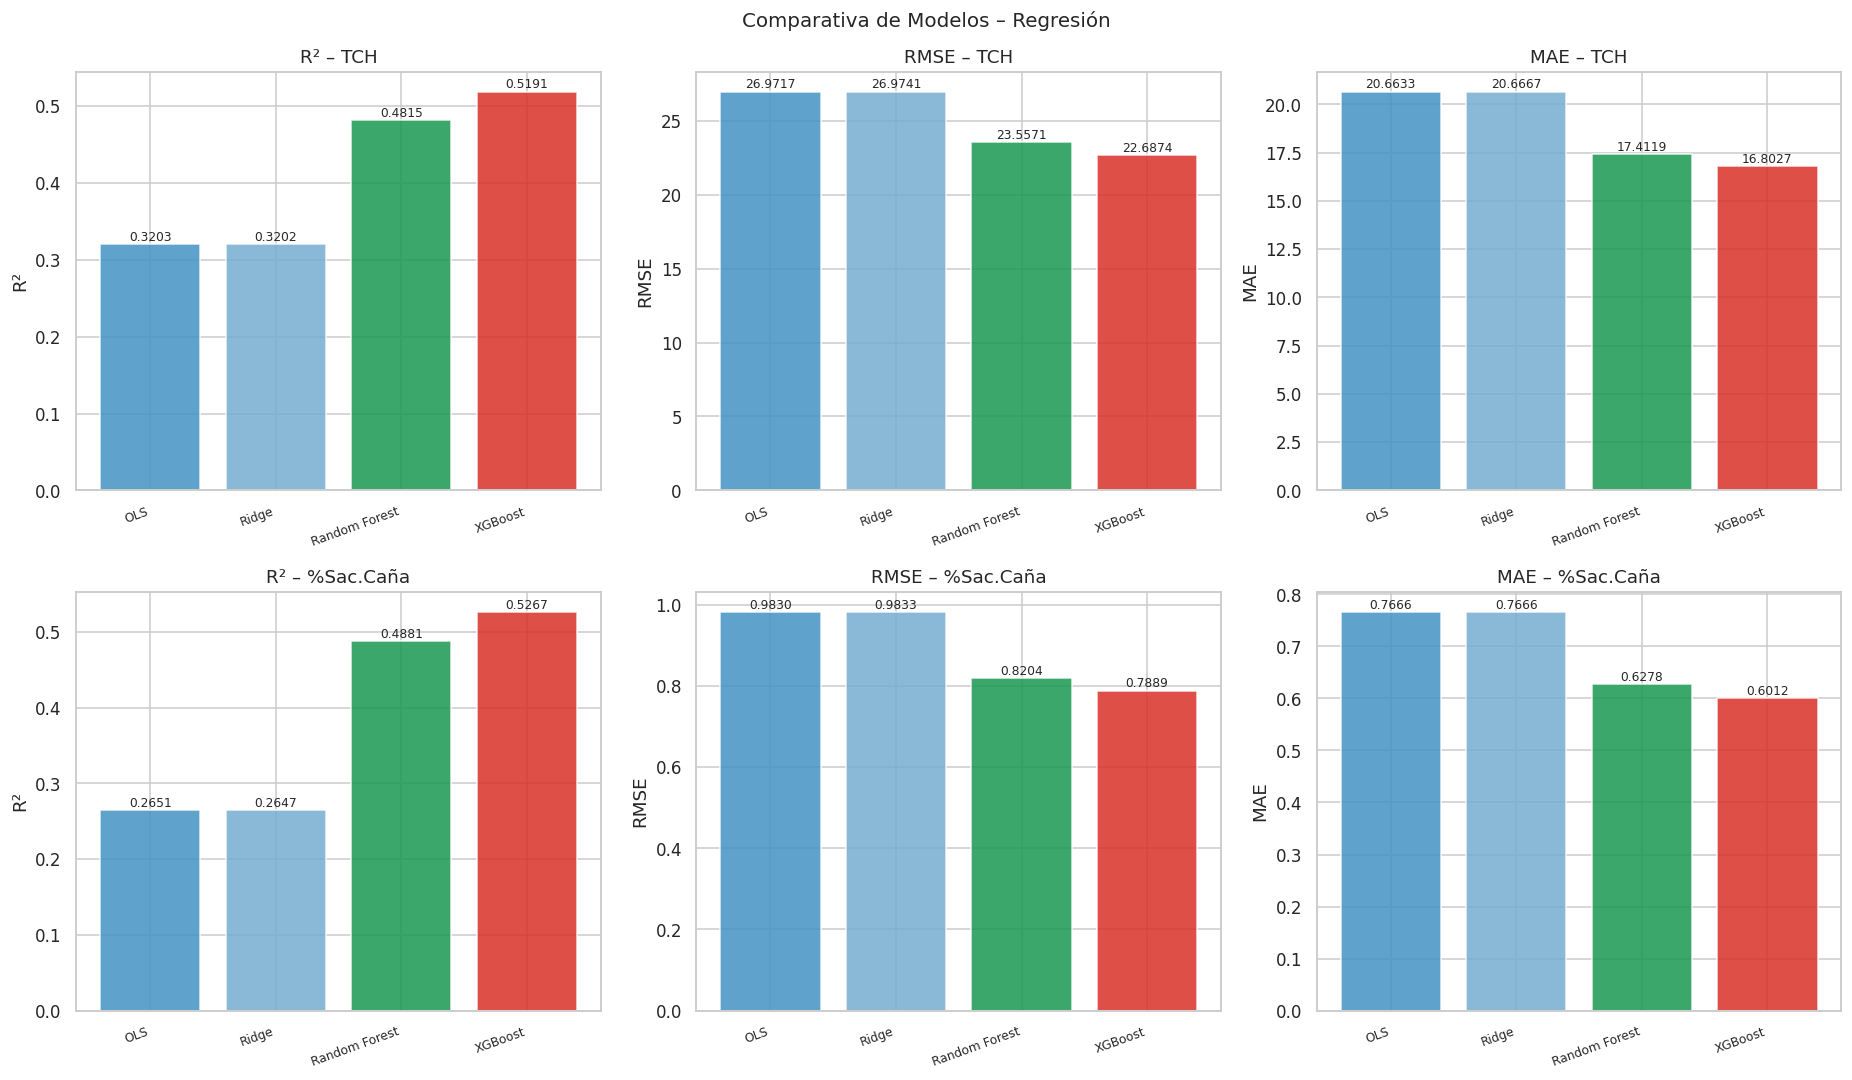

In [12]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

metricas = ['R²', 'RMSE', 'MAE']
colores = {'OLS': '#4393c3', 'Ridge': '#74add1', 'Random Forest': '#1a9850', 'XGBoost': '#d73027'}

for row, target in enumerate(TARGETS_REG):
    sub = tabla_reg[tabla_reg['Target'] == target]
    for col, metrica in enumerate(metricas):
        ax = axes[row, col]
        colors = [colores[m] for m in sub['Modelo']]
        bars = ax.bar(sub['Modelo'], sub[metrica], color=colors, edgecolor='white', alpha=0.85)
        for bar, val in zip(bars, sub[metrica]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.001 * sub[metrica].max(),
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8)
            
        ax.set_title(f'{metrica} – {target}')
        ax.set_ylabel(metrica)
        plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)

plt.suptitle('Comparativa de Modelos – Regresión', fontsize=13)
plt.tight_layout()
plt.show()

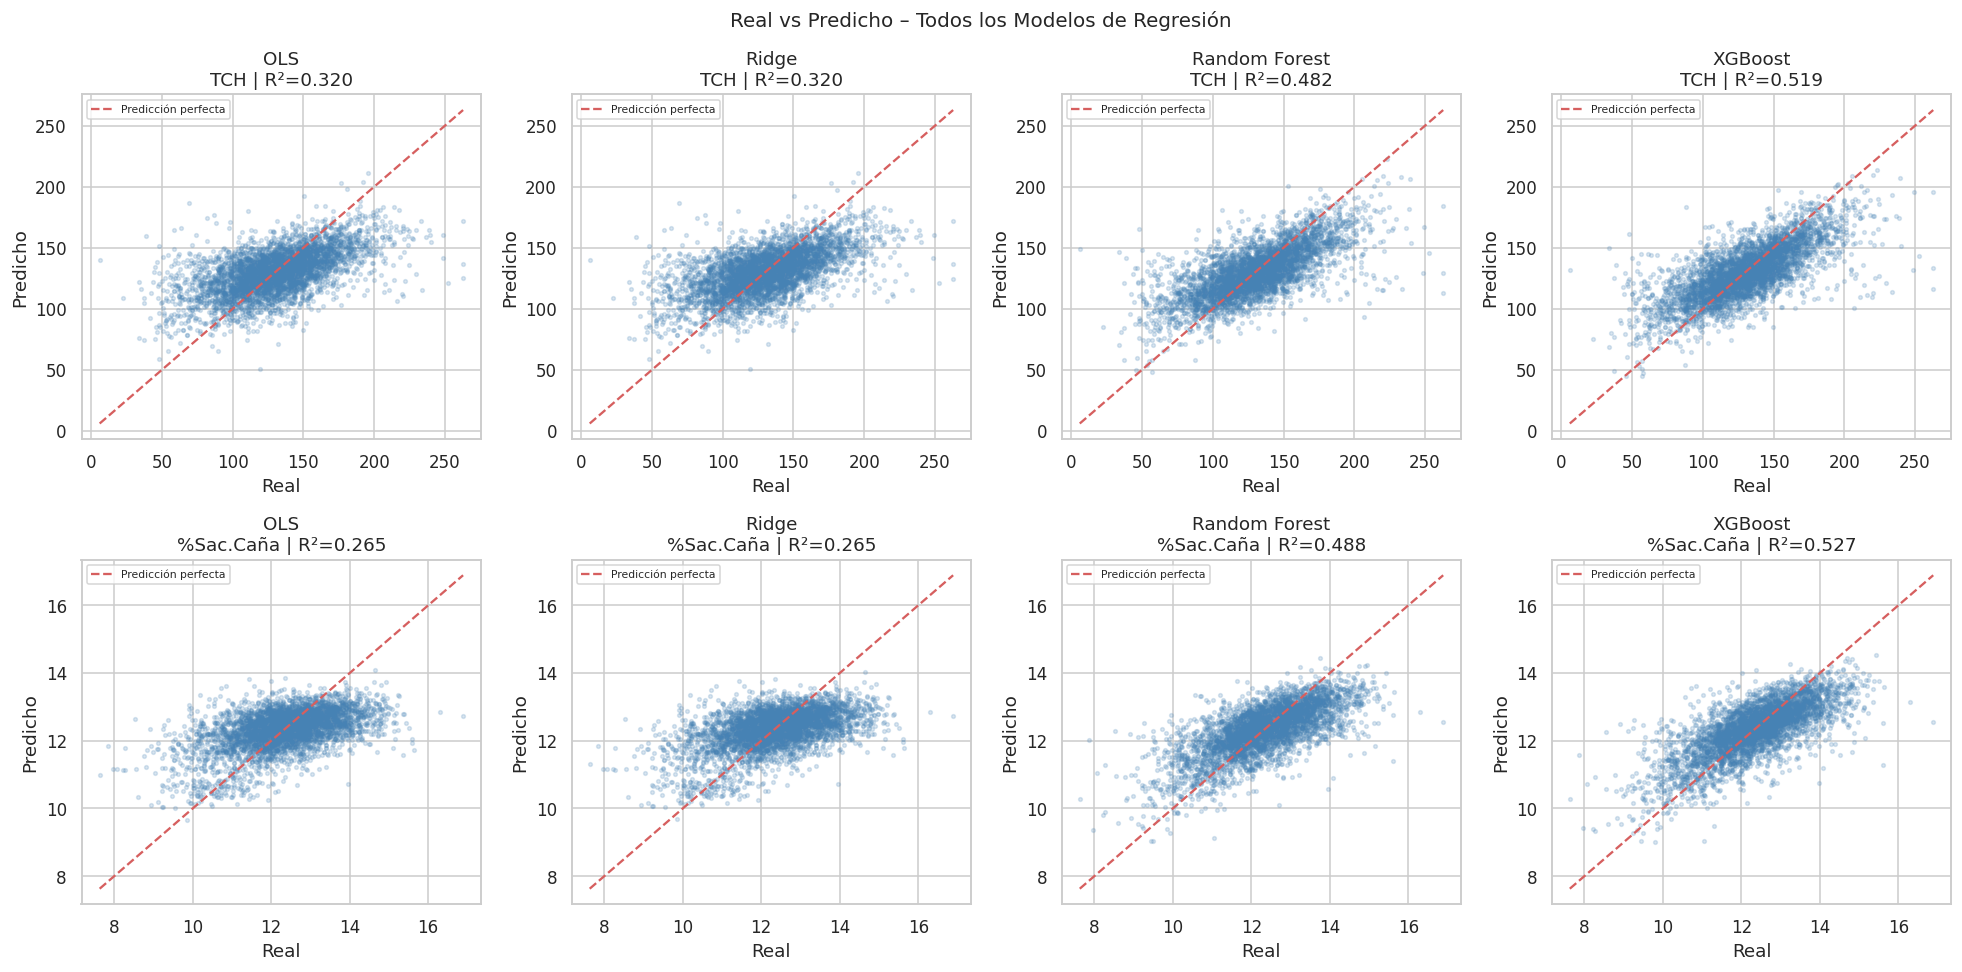

In [13]:
# Real vs Predicho – mejor modelo por target
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row, target in enumerate(TARGETS_REG):
    for col, (nombre, resultados) in enumerate(modelos_reg.items()):
        ax = axes[row, col]
        y_test = resultados[target]['y_test']
        y_pred = resultados[target]['y_pred']
        r2 = resultados[target]['R2']

        ax.scatter(y_test, y_pred, alpha=0.2, s=6, color='steelblue')
        lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
        ax.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
        ax.set_xlabel('Real')
        ax.set_ylabel('Predicho')
        ax.set_title(f'{nombre}\n{target} | R²={r2:.3f}')
        ax.legend(fontsize=7)

plt.suptitle('Real vs Predicho – Todos los Modelos de Regresión', fontsize=13)
plt.tight_layout()
plt.show()

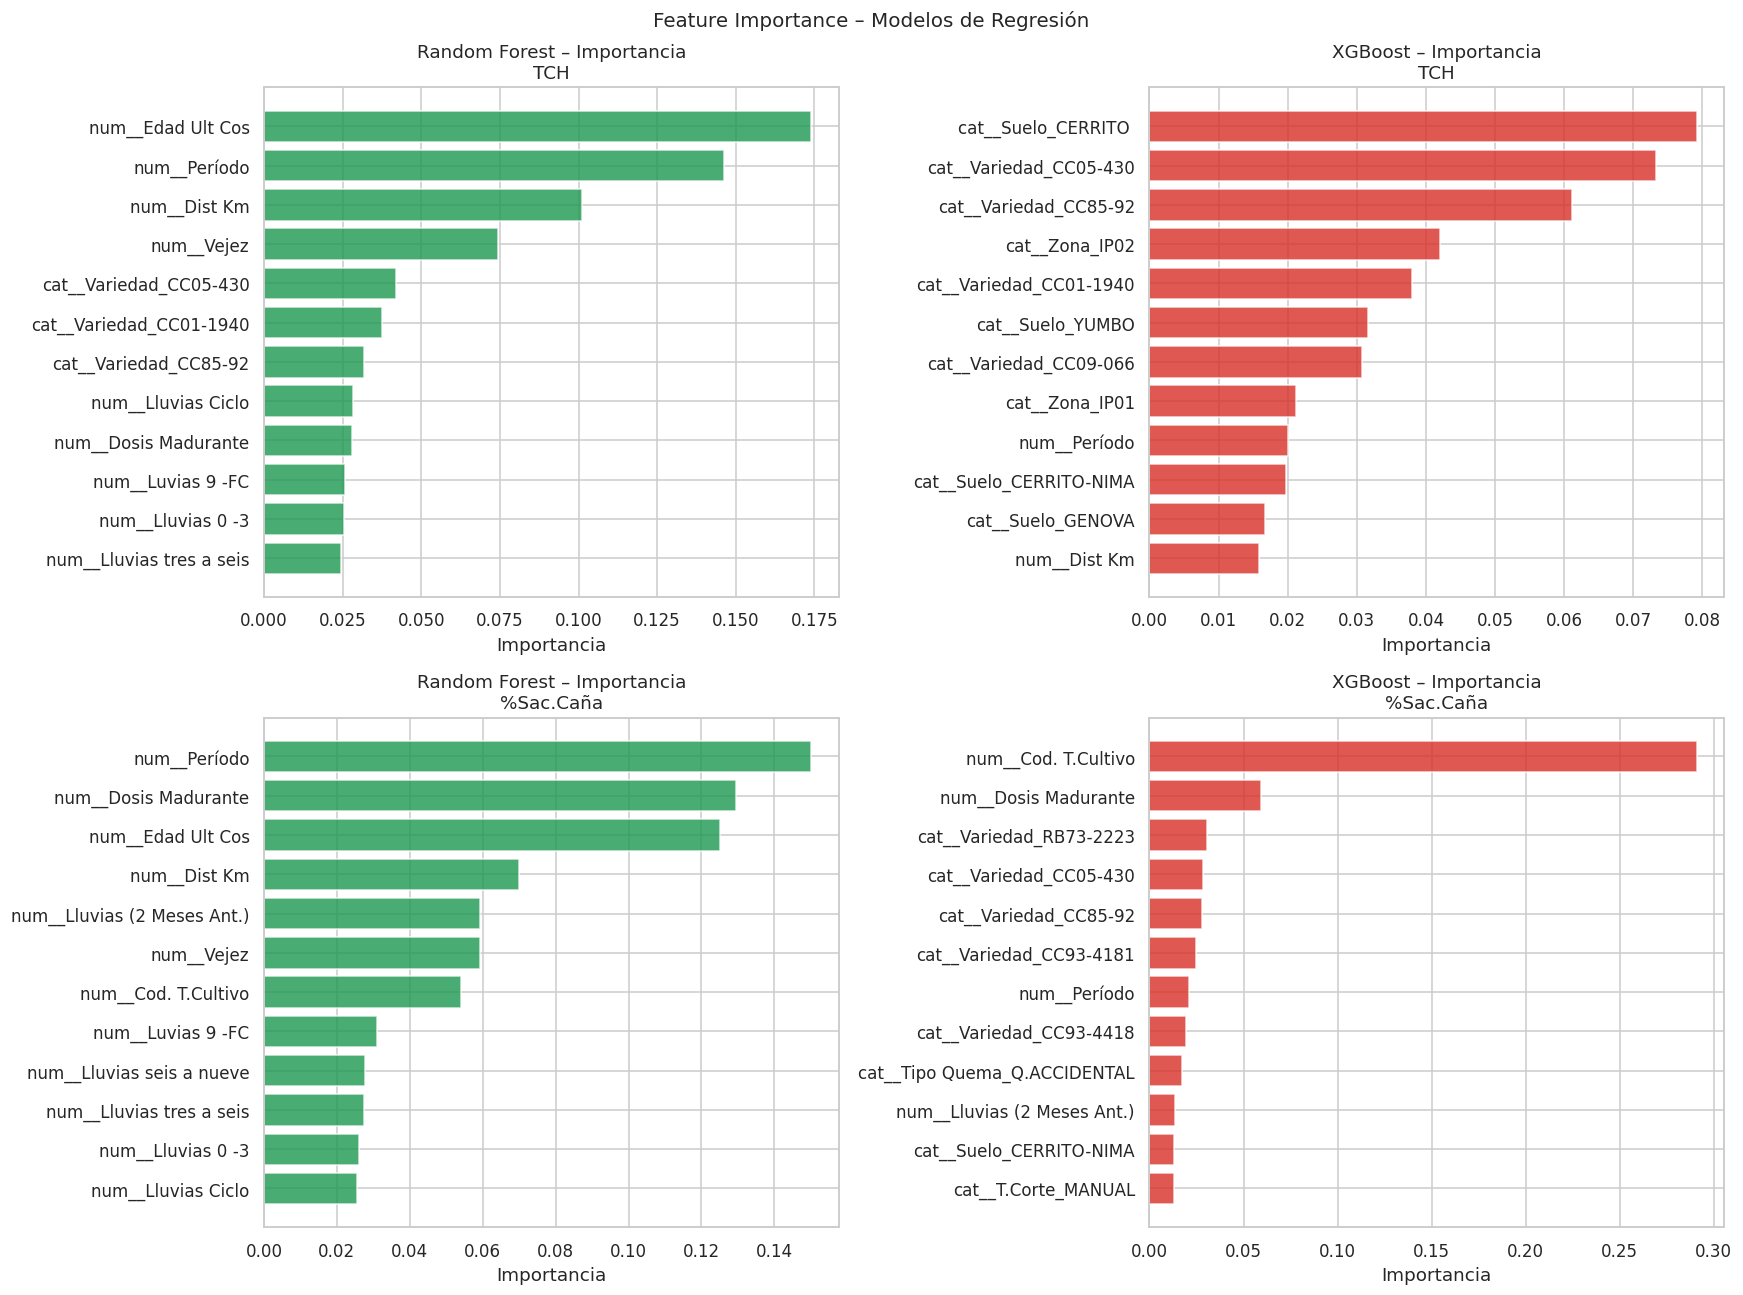

In [14]:
# Feature Importance – RF y XGBoost. Tomamos los nombres post-OHE del preprocessor.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, target in enumerate(TARGETS_REG):
    for col, (nombre, resultados) in enumerate([('Random Forest', resultados_rf_reg),
                                                 ('XGBoost', resultados_xgb_reg)]):
        ax = axes[row, col]
        pipe = resultados[target]['modelo']
        # Nombres de features post-OHE
        feat_names = list(pipe.named_steps['prep'].get_feature_names_out())
        modelo_final = pipe.named_steps['rf' if nombre == 'Random Forest' else 'xgb']
        importancias = modelo_final.feature_importances_

        imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importancias})
        imp_df = imp_df.nlargest(12, 'Importance')
        color = '#1a9850' if nombre == 'Random Forest' else '#d73027'
        ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=color, alpha=0.8)
        ax.set_title(f'{nombre} – Importancia\n{target}')
        ax.set_xlabel('Importancia')

plt.suptitle('Feature Importance – Modelos de Regresión', fontsize=13)
plt.tight_layout()
plt.show()

---
# SECCIÓN 2 – CLASIFICACIÓN
## 8. División Train / Test (80 / 20)

In [15]:
# Split estratificado independiente para cada target (más justo que estratificar solo por uno).
# Mantenemos el mismo split entre modelos para comparar manzanas con manzanas.
X_clf_full = df_clf[NUM_CLF + CAT_CLF]

splits_clf = {}
for t in TARGETS_CLF:
    y = df_clf[t].values
    idx_c = np.arange(len(df_clf))
    tr, te = train_test_split(idx_c, test_size=0.2, random_state=SEED, stratify=y)
    splits_clf[t] = {'train': tr, 'test': te, 'y_train': y[tr], 'y_test': y[te]}

# Preprocesador de clasificación (solo numéricas tras filtrar constantes)
prep_clf_lin = ColumnTransformer([
    ('num', StandardScaler(), NUM_CLF),
])
prep_clf_tree = ColumnTransformer([
    ('num', 'passthrough', NUM_CLF),
])

print(f'Train: {len(splits_clf[TARGETS_CLF[0]]["train"])} | Test: {len(splits_clf[TARGETS_CLF[0]]["test"])}')
for t in TARGETS_CLF:
    y_tr = splits_clf[t]['y_train']
    vals, cnts = np.unique(y_tr, return_counts=True)
    print(f'  {t} train: {dict(zip(LABELS_CLF, cnts))}')

Train: 1749 | Test: 438
  nivel_TCH_num train: {'Bajo': np.int64(603), 'Medio': np.int64(564), 'Alto': np.int64(582)}
  nivel_sacarosa_num train: {'Bajo': np.int64(608), 'Medio': np.int64(568), 'Alto': np.int64(573)}


---
## 9. Benchmark – Regresión Logística Multinomial (L2)

In [16]:
# Regresión Logística multinomial con regularización L2.
# Pipeline: scaler + LogisticRegression. GridSearch sobre C.
resultados_lr = {}

for target in TARGETS_CLF:
    s = splits_clf[target]
    X_train = X_clf_full.iloc[s['train']]
    X_test  = X_clf_full.iloc[s['test']]
    y_train, y_test = s['y_train'], s['y_test']

    pipe = Pipeline([
        ('prep', prep_clf_lin),
        ('lr', LogisticRegression(solver='lbfgs', penalty='l2',
                                   max_iter=2000, random_state=SEED))
    ])
    gs = GridSearchCV(
        pipe, {'lr__C': [0.001, 0.01, 0.1, 1, 10, 100]},
        cv=5, scoring='f1_macro', n_jobs=-1
    )
    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    y_pred  = best.predict(X_test)
    y_proba = best.predict_proba(X_test)

    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average='macro')
    rec   = recall_score(y_test, y_pred, average='macro')

    resultados_lr[target] = {
        'modelo': best, 'y_test': y_test, 'y_pred': y_pred, 'y_proba': y_proba,
        'Accuracy': acc, 'F1': f1, 'Kappa': kappa, 'Precision': prec, 'Recall': rec,
        'best_C': gs.best_params_['lr__C']
    }

    nombre = target.replace('_num', '').replace('nivel_', 'nivel ')
    print(f'Logística L2 – {nombre}')
    print(f'  C óptimo (5-fold CV): {gs.best_params_["lr__C"]}')
    print(f'  Accuracy={acc:.4f} | F1-macro={f1:.4f} | Kappa={kappa:.4f}\n')
    print(classification_report(y_test, y_pred, target_names=LABELS_CLF))
    print()

Logística L2 – nivel TCH
  C óptimo (5-fold CV): 1
  Accuracy=0.4361 | F1-macro=0.4222 | Kappa=0.1501

              precision    recall  f1-score   support

        Bajo       0.42      0.54      0.47       151
       Medio       0.47      0.24      0.32       141
        Alto       0.44      0.52      0.48       146

    accuracy                           0.44       438
   macro avg       0.44      0.43      0.42       438
weighted avg       0.44      0.44      0.42       438


Logística L2 – nivel sacarosa
  C óptimo (5-fold CV): 1
  Accuracy=0.4589 | F1-macro=0.4369 | Kappa=0.1847

              precision    recall  f1-score   support

        Bajo       0.49      0.63      0.55       153
       Medio       0.39      0.21      0.28       142
        Alto       0.45      0.52      0.49       143

    accuracy                           0.46       438
   macro avg       0.45      0.45      0.44       438
weighted avg       0.45      0.46      0.44       438




---
## 10. Benchmark – KNN (optimización de k)

In [17]:
# KNN con escalado obligatorio (KNN es métrico-sensible).
resultados_knn = {}
ks = list(range(3, 32, 2))

for target in TARGETS_CLF:
    s = splits_clf[target]
    X_train = X_clf_full.iloc[s['train']]
    X_test  = X_clf_full.iloc[s['test']]
    y_train, y_test = s['y_train'], s['y_test']

    pipe = Pipeline([
        ('prep', prep_clf_lin),
        ('knn', KNeighborsClassifier(metric='minkowski'))
    ])
    gs = GridSearchCV(
        pipe,
        {'knn__n_neighbors': ks, 'knn__weights': ['uniform', 'distance']},
        cv=5, scoring='f1_macro', n_jobs=-1
    )
    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    y_pred  = best.predict(X_test)
    y_proba = best.predict_proba(X_test)

    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average='macro')
    rec   = recall_score(y_test, y_pred, average='macro')

    # Curva F1 vs k para diagnóstico
    cv_scores_k = {}
    for w in ['uniform', 'distance']:
        scores = []
        for k in ks:
            p = Pipeline([('prep', prep_clf_lin),
                          ('knn', KNeighborsClassifier(n_neighbors=k, weights=w, metric='minkowski'))])
            scores.append(cross_val_score(p, X_train, y_train, cv=5, scoring='f1_macro').mean())
        cv_scores_k[w] = scores

    resultados_knn[target] = {
        'modelo': best, 'y_test': y_test, 'y_pred': y_pred, 'y_proba': y_proba,
        'Accuracy': acc, 'F1': f1, 'Kappa': kappa, 'Precision': prec, 'Recall': rec,
        'best_k': gs.best_params_['knn__n_neighbors'],
        'best_w': gs.best_params_['knn__weights'],
        'cv_scores_k': cv_scores_k
    }

    nombre = target.replace('_num', '').replace('nivel_', 'nivel ')
    print(f'KNN – {nombre}')
    print(f'  k óptimo={gs.best_params_["knn__n_neighbors"]} | weights={gs.best_params_["knn__weights"]}')
    print(f'  Accuracy={acc:.4f} | F1-macro={f1:.4f} | Kappa={kappa:.4f}\n')

KNN – nivel TCH
  k óptimo=29 | weights=distance
  Accuracy=0.4338 | F1-macro=0.4272 | Kappa=0.1498



KNN – nivel sacarosa
  k óptimo=27 | weights=distance
  Accuracy=0.4977 | F1-macro=0.4860 | Kappa=0.2451



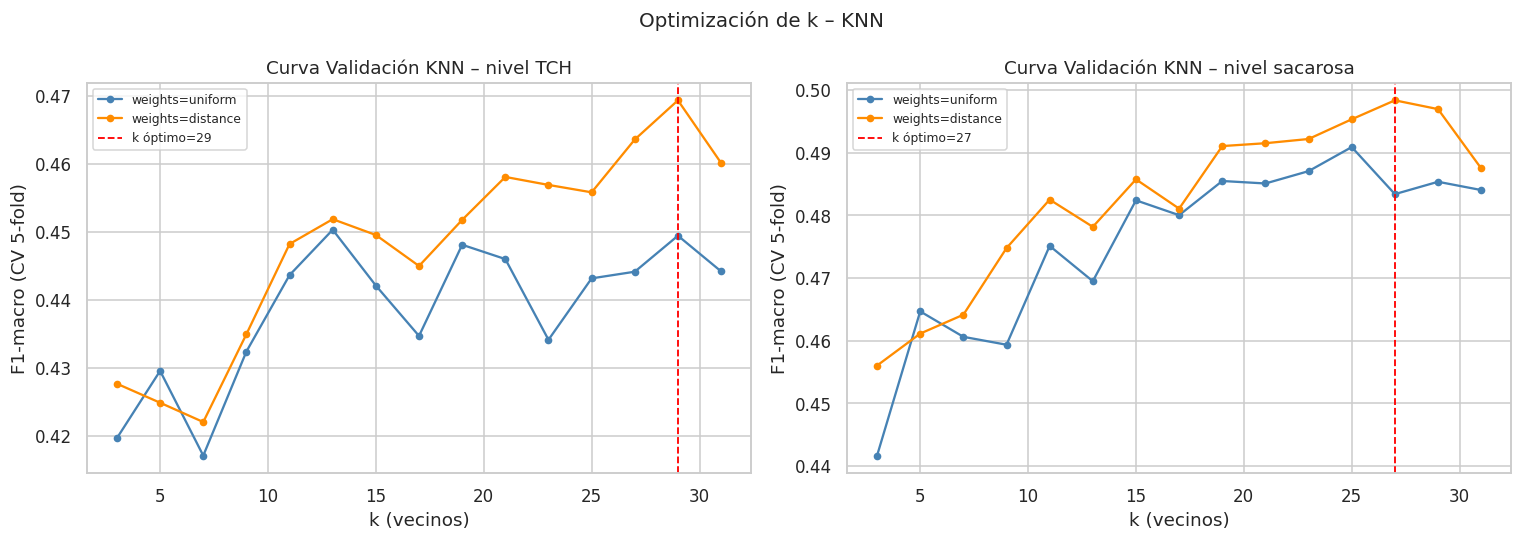

In [18]:
# Curva F1 vs k para KNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, TARGETS_CLF):
    r = resultados_knn[target]
    nombre = target.replace('_num', '').replace('nivel_', 'nivel ')
    for w, color in [('uniform', 'steelblue'), ('distance', 'darkorange')]:
        ax.plot(ks, r['cv_scores_k'][w], marker='o', markersize=4, color=color, label=f'weights={w}')
    ax.axvline(r['best_k'], color='red', linestyle='--', linewidth=1.2,
               label=f'k óptimo={r["best_k"]}')
    ax.set_xlabel('k (vecinos)')
    ax.set_ylabel('F1-macro (CV 5-fold)')
    ax.set_title(f'Curva Validación KNN – {nombre}')
    ax.legend(fontsize=8)

plt.suptitle('Optimización de k – KNN', fontsize=13)
plt.tight_layout()
plt.show()

---
## 11. Modelo Avanzado – Random Forest Classifier

In [19]:
resultados_rf_clf = {}

param_dist_rfc = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 8, 15, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 0.5]
}

for target in TARGETS_CLF:
    s = splits_clf[target]
    X_train = X_clf_full.iloc[s['train']]
    X_test  = X_clf_full.iloc[s['test']]
    y_train, y_test = s['y_train'], s['y_test']

    pipe = Pipeline([
        ('prep', prep_clf_tree),
        ('rf',   RandomForestClassifier(random_state=SEED, n_jobs=2, class_weight='balanced'))
    ])
    rs = RandomizedSearchCV(
        pipe, param_dist_rfc, n_iter=20, cv=5,
        scoring='f1_macro', random_state=SEED, n_jobs=2
    )
    rs.fit(X_train, y_train)
    best = rs.best_estimator_
    y_pred  = best.predict(X_test)
    y_proba = best.predict_proba(X_test)

    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average='macro')
    rec   = recall_score(y_test, y_pred, average='macro')

    resultados_rf_clf[target] = {
        'modelo': best, 'y_test': y_test, 'y_pred': y_pred, 'y_proba': y_proba,
        'Accuracy': acc, 'F1': f1, 'Kappa': kappa, 'Precision': prec, 'Recall': rec,
        'best_params': rs.best_params_
    }

    nombre = target.replace('_num', '').replace('nivel_', 'nivel ')
    print(f'RF Classifier – {nombre}')
    print(f'  Params: {rs.best_params_}')
    print(f'  Accuracy={acc:.4f} | F1-macro={f1:.4f} | Kappa={kappa:.4f}\n')


RF Classifier – nivel TCH
  Params: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 20}
  Accuracy=0.4703 | F1-macro=0.4683 | Kappa=0.2045



RF Classifier – nivel sacarosa
  Params: {'rf__n_estimators': 200, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': 20}
  Accuracy=0.5297 | F1-macro=0.5192 | Kappa=0.2925



---
## 12. Modelo Avanzado – XGBoost Classifier

In [20]:
resultados_xgb_clf = {}

param_grid_xgbc = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

for target in TARGETS_CLF:
    s = splits_clf[target]
    X_train = X_clf_full.iloc[s['train']]
    X_test  = X_clf_full.iloc[s['test']]
    y_train, y_test = s['y_train'], s['y_test']

    pipe = Pipeline([
        ('prep', prep_clf_tree),
        ('xgb',  XGBClassifier(random_state=SEED, verbosity=0, n_jobs=2,
                                eval_metric='mlogloss'))
    ])
    rs = RandomizedSearchCV(
        pipe, param_grid_xgbc, n_iter=20, cv=5,
        scoring='f1_macro', random_state=SEED, n_jobs=2
    )
    rs.fit(X_train, y_train)
    best = rs.best_estimator_
    y_pred  = best.predict(X_test)
    y_proba = best.predict_proba(X_test)

    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average='macro')
    rec   = recall_score(y_test, y_pred, average='macro')

    resultados_xgb_clf[target] = {
        'modelo': best, 'y_test': y_test, 'y_pred': y_pred, 'y_proba': y_proba,
        'Accuracy': acc, 'F1': f1, 'Kappa': kappa, 'Precision': prec, 'Recall': rec,
        'best_params': rs.best_params_
    }

    nombre = target.replace('_num', '').replace('nivel_', 'nivel ')
    print(f'XGBoost Classifier – {nombre}')
    print(f'  Params: {rs.best_params_}')
    print(f'  Accuracy={acc:.4f} | F1-macro={f1:.4f} | Kappa={kappa:.4f}\n')


XGBoost Classifier – nivel TCH
  Params: {'xgb__subsample': 1.0, 'xgb__n_estimators': 200, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 1.0}
  Accuracy=0.4429 | F1-macro=0.4426 | Kappa=0.1643



XGBoost Classifier – nivel sacarosa
  Params: {'xgb__subsample': 1.0, 'xgb__n_estimators': 300, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 1.0}
  Accuracy=0.5091 | F1-macro=0.5050 | Kappa=0.2628



---
## 13. Matrices de Confusión – Todos los Modelos

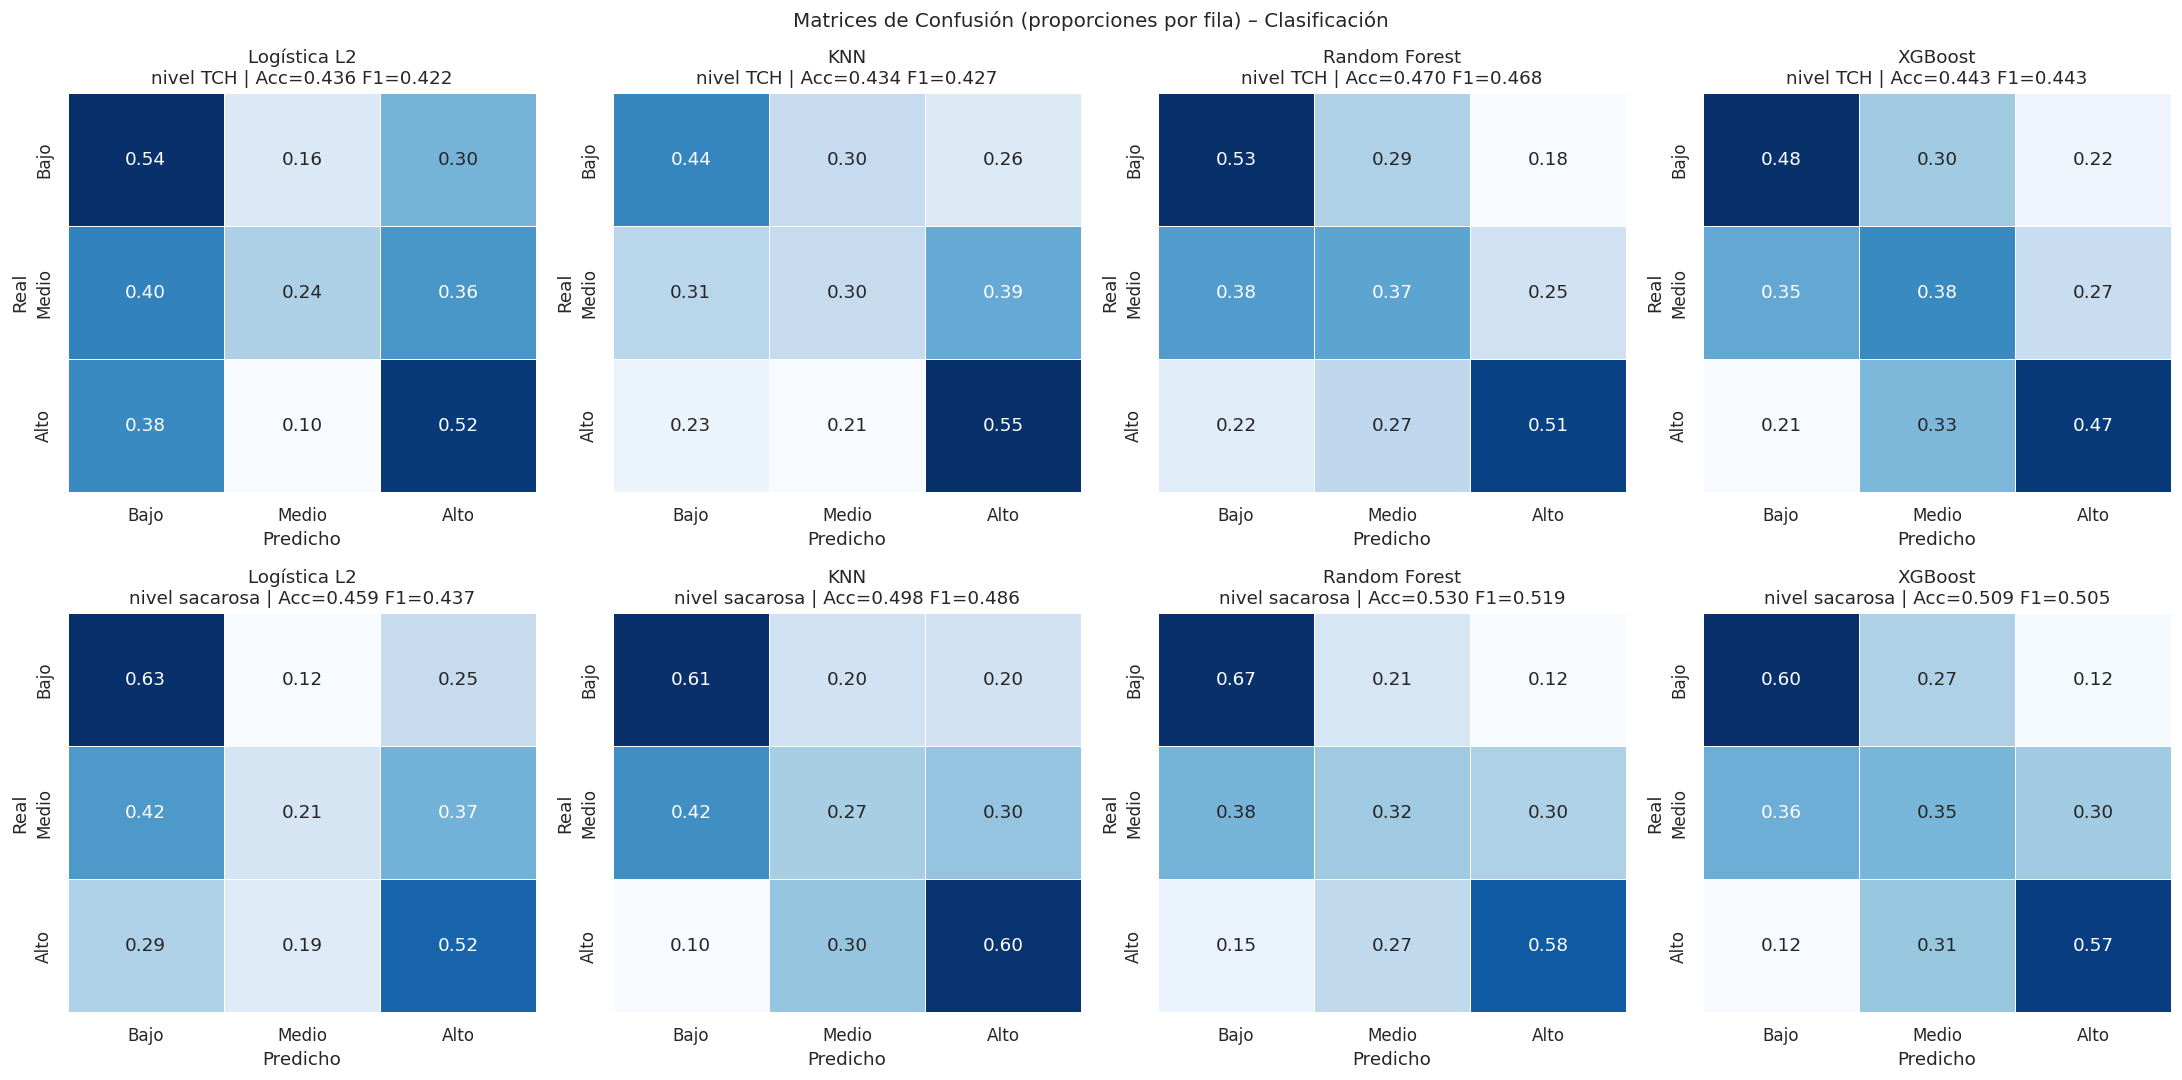

In [21]:
modelos_clf = {
    'Logística L2': resultados_lr,
    'KNN':          resultados_knn,
    'Random Forest':resultados_rf_clf,
    'XGBoost':      resultados_xgb_clf,
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for row, target in enumerate(TARGETS_CLF):
    nombre_target = target.replace('_num', '').replace('nivel_', 'nivel ')
    for col, (nombre_m, resultados) in enumerate(modelos_clf.items()):
        ax = axes[row, col]
        y_test = resultados[target]['y_test']
        y_pred = resultados[target]['y_pred']
        cm = confusion_matrix(y_test, y_pred)
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=LABELS_CLF, yticklabels=LABELS_CLF,
                    ax=ax, cbar=False, linewidths=0.5)
        acc = resultados[target]['Accuracy']
        f1  = resultados[target]['F1']
        ax.set_title(f'{nombre_m}\n{nombre_target} | Acc={acc:.3f} F1={f1:.3f}')
        ax.set_xlabel('Predicho')
        ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión (proporciones por fila) – Clasificación', fontsize=13)
plt.tight_layout()
plt.show()

---
## 14. Comparativa de Modelos – Clasificación

In [22]:
filas_clf = []
for nombre, resultados in modelos_clf.items():
    for target in TARGETS_CLF:
        r = resultados[target]
        nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
        filas_clf.append({
            'Modelo': nombre, 'Target': nombre_t,
            'Accuracy': round(r['Accuracy'], 4),
            'Precision': round(r['Precision'], 4),
            'Recall': round(r['Recall'], 4),
            'F1-macro': round(r['F1'], 4),
            'Kappa': round(r['Kappa'], 4)
        })

tabla_clf = pd.DataFrame(filas_clf)
print('TABLA COMPARATIVA – CLASIFICACIÓN (evaluación en test set 20%)')
print(tabla_clf.to_string(index=False))

TABLA COMPARATIVA – CLASIFICACIÓN (evaluación en test set 20%)
       Modelo         Target  Accuracy  Precision  Recall  F1-macro  Kappa
 Logística L2      nivel TCH    0.4361     0.4437  0.4327    0.4222 0.1501
 Logística L2 nivel sacarosa    0.4589     0.4455  0.4544    0.4369 0.1847
          KNN      nivel TCH    0.4338     0.4270  0.4321    0.4272 0.1498
          KNN nivel sacarosa    0.4977     0.4820  0.4946    0.4860 0.2451
Random Forest      nivel TCH    0.4703     0.4695  0.4685    0.4683 0.2045
Random Forest nivel sacarosa    0.5297     0.5175  0.5259    0.5192 0.2925
      XGBoost      nivel TCH    0.4429     0.4436  0.4419    0.4426 0.1643
      XGBoost nivel sacarosa    0.5091     0.5038  0.5066    0.5050 0.2628


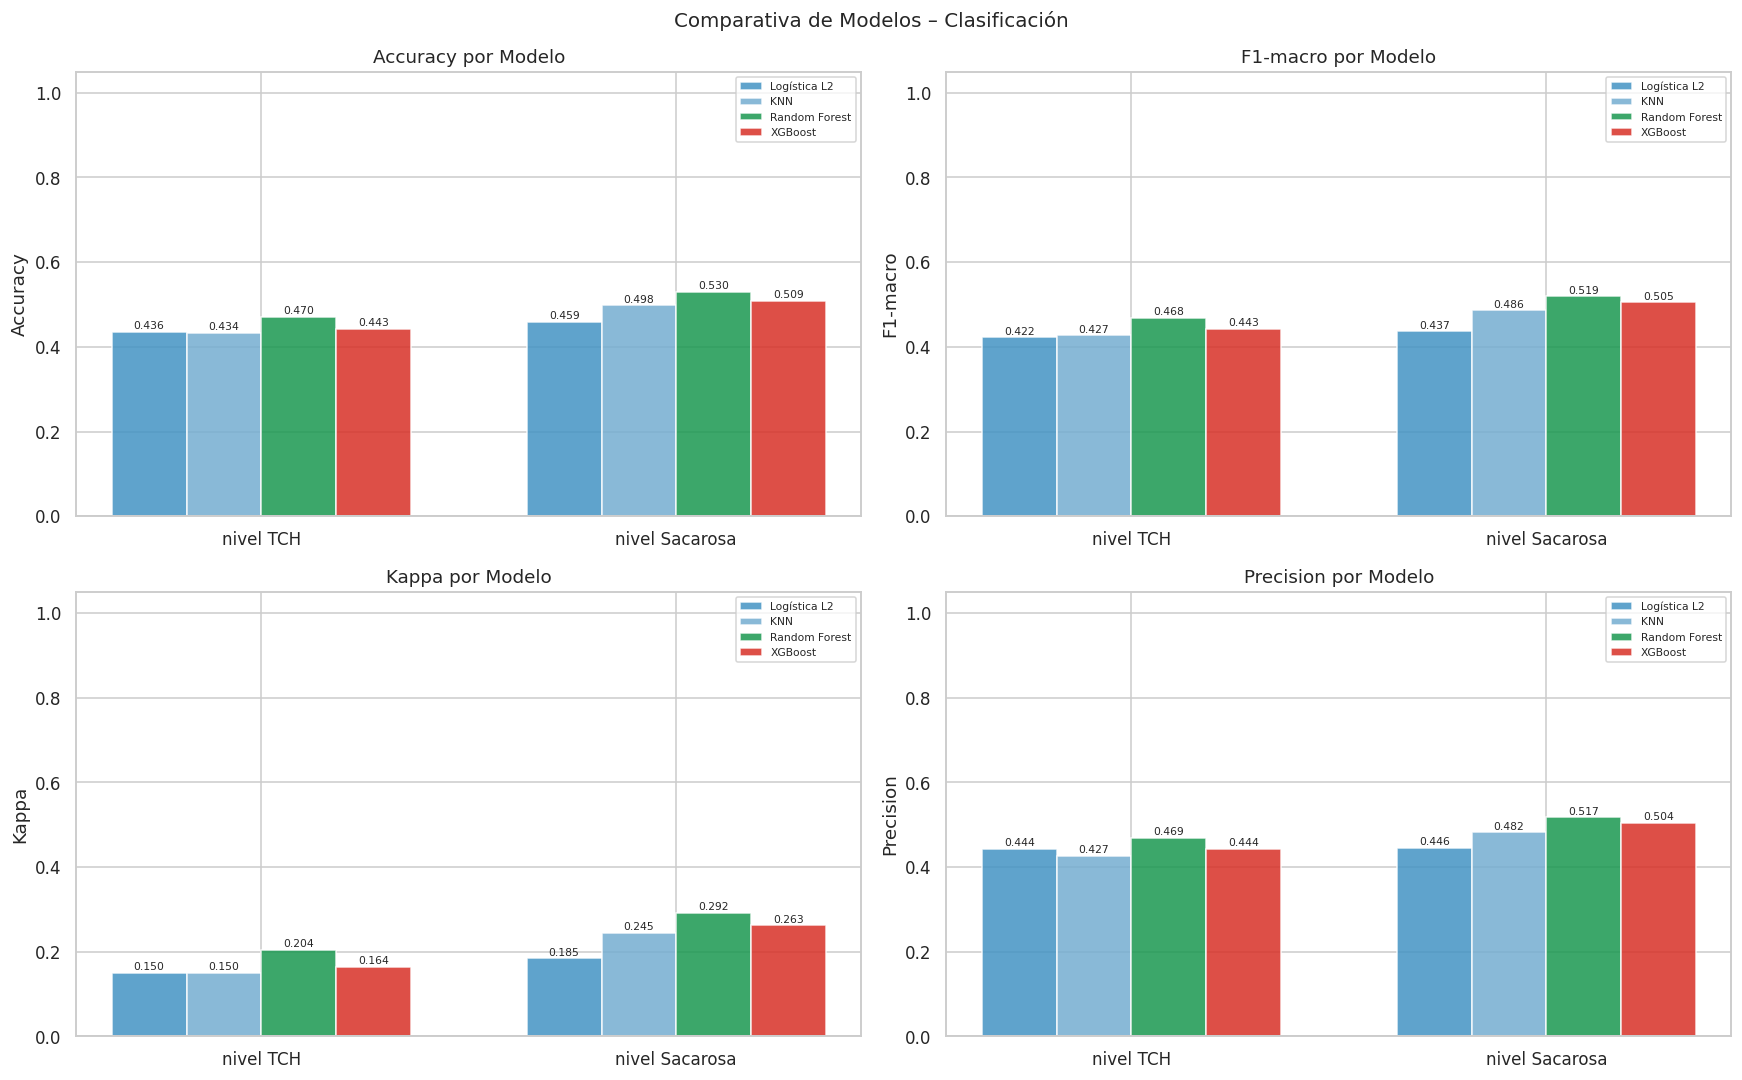

In [23]:
# Gráfico comparativo clasificación
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metricas_clf = ['Accuracy', 'F1-macro', 'Kappa', 'Precision']
colores_clf = {'Logística L2': '#4393c3', 'KNN': '#74add1', 'Random Forest': '#1a9850', 'XGBoost': '#d73027'}

for ax, metrica in zip(axes.flatten(), metricas_clf):
    x = np.arange(2)
    width = 0.18
    for i, (nombre, color) in enumerate(colores_clf.items()):
        vals = []
        for target in TARGETS_CLF:
            nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
            vals.append(tabla_clf[(tabla_clf['Modelo'] == nombre) & (tabla_clf['Target'] == nombre_t)][metrica].values[0])
        bars = ax.bar(x + i*width - 1.5*width, vals, width, label=nombre, color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(['nivel TCH', 'nivel Sacarosa'])
    ax.set_ylabel(metrica)
    ax.set_title(f'{metrica} por Modelo')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)

plt.suptitle('Comparativa de Modelos – Clasificación', fontsize=13)
plt.tight_layout()
plt.show()

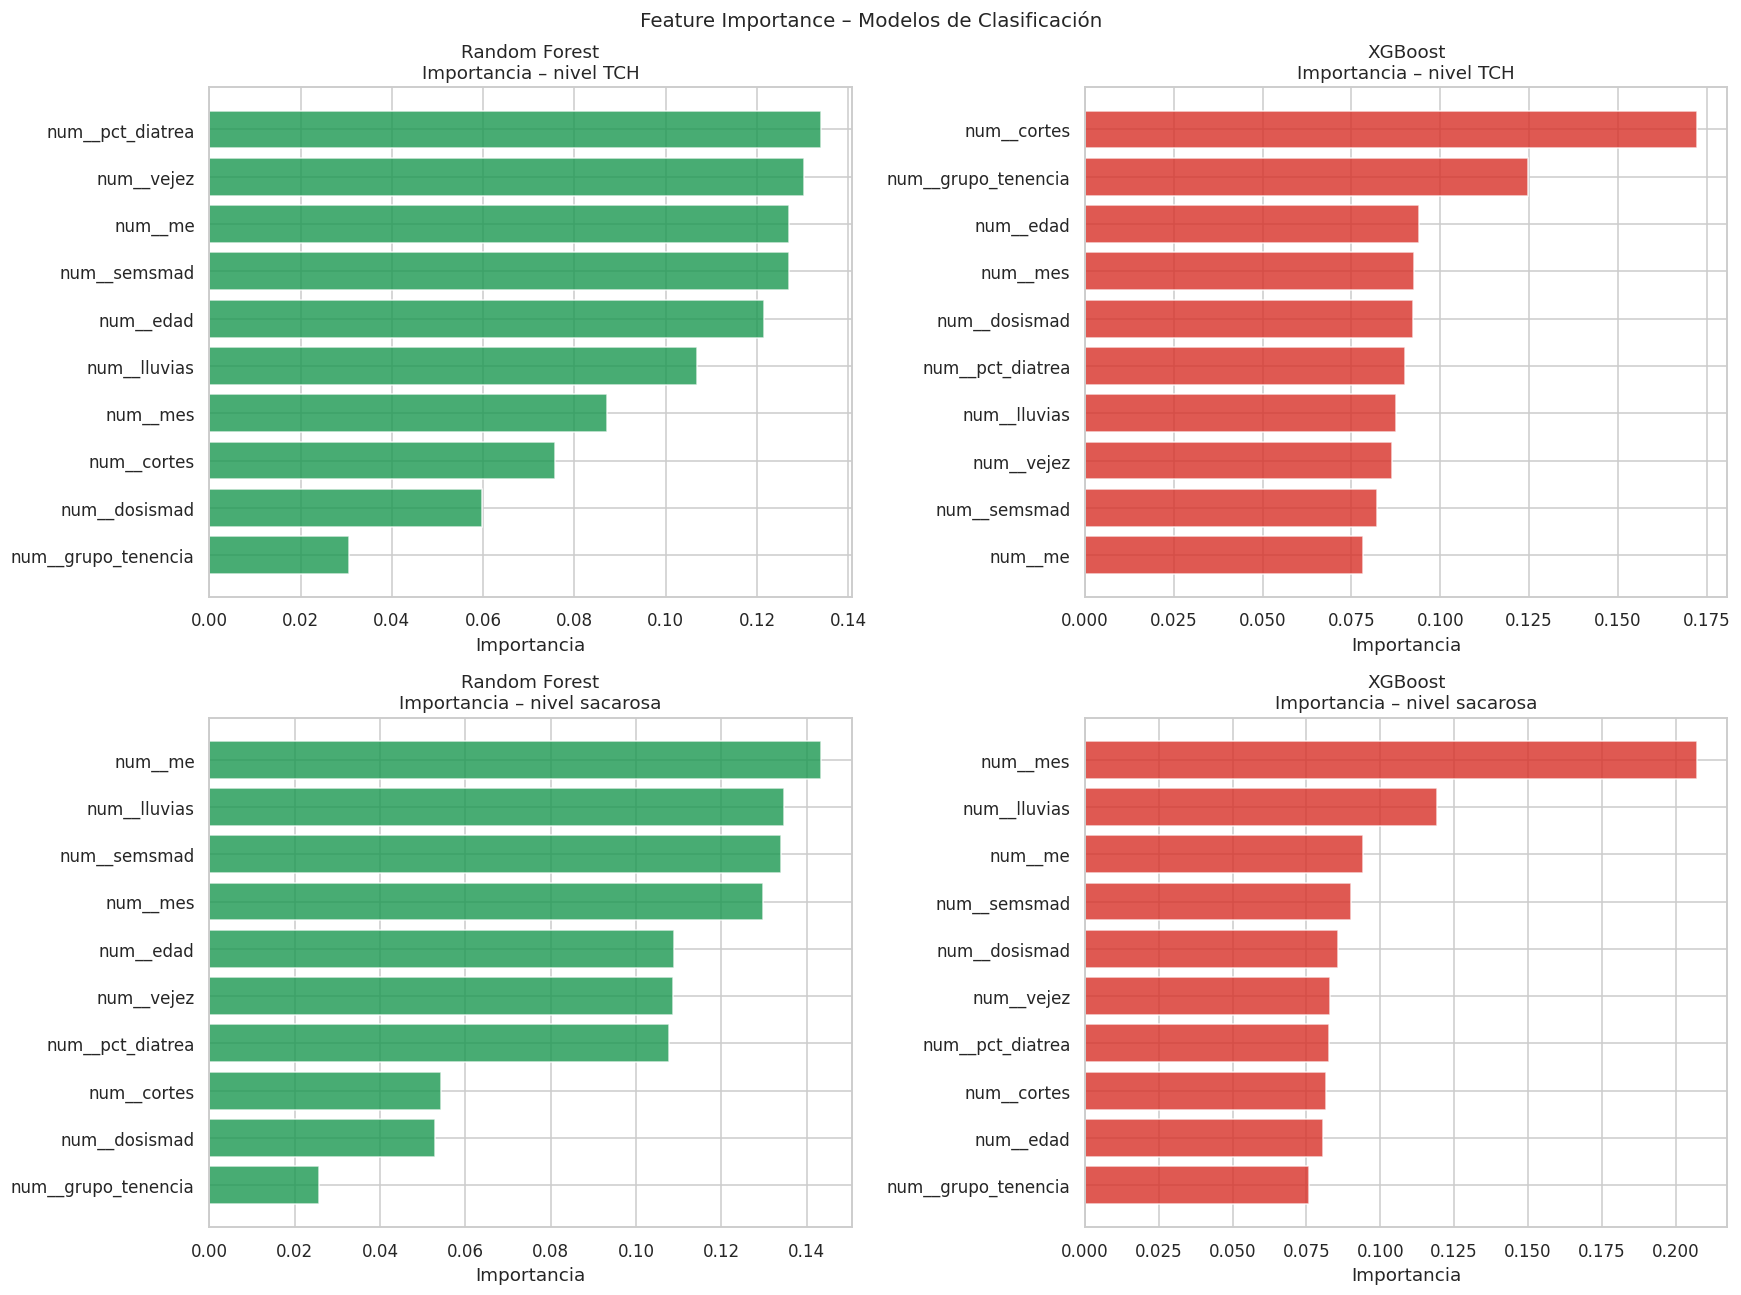

In [24]:
# Feature Importance – Clasificación (RF y XGBoost). Como no hay categóricas tras
# descartar las constantes, los nombres de features son los originales.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, target in enumerate(TARGETS_CLF):
    nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
    for col, (nombre, resultados) in enumerate([('Random Forest', resultados_rf_clf),
                                                 ('XGBoost', resultados_xgb_clf)]):
        ax = axes[row, col]
        pipe = resultados[target]['modelo']
        feat_names = list(pipe.named_steps['prep'].get_feature_names_out())
        modelo_final = pipe.named_steps['rf' if nombre == 'Random Forest' else 'xgb']
        importancias = modelo_final.feature_importances_

        imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importancias})
        imp_df = imp_df.nlargest(10, 'Importance')
        color = '#1a9850' if nombre == 'Random Forest' else '#d73027'
        ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=color, alpha=0.8)
        ax.set_title(f'{nombre}\nImportancia – {nombre_t}')
        ax.set_xlabel('Importancia')

plt.suptitle('Feature Importance – Modelos de Clasificación', fontsize=13)
plt.tight_layout()
plt.show()

---
## 15. Resumen Ejecutivo – Tarea 3

In [25]:
sep = '='*68
print(sep)
print('RESUMEN EJECUTIVO – TAREA 3: MODELAMIENTO')
print(sep)

print('\n── REGRESIÓN ─────────────────────────────────────────────────')
print(tabla_reg.sort_values(['Target', 'R²'], ascending=[True, False]).to_string(index=False))

print('\n── CLASIFICACIÓN ──────────────────────────────────────────────')
print(tabla_clf.sort_values(['Target', 'F1-macro'], ascending=[True, False]).to_string(index=False))

print('\n── MEJORES MODELOS POR TASK ───────────────────────────────────')
for target in TARGETS_REG:
    mejor_r2 = tabla_reg[tabla_reg['Target'] == target].nlargest(1, 'R²').iloc[0]
    print(f'  [REG] {target}: ganador = {mejor_r2["Modelo"]} '
          f'(R²={mejor_r2["R²"]:.4f}, RMSE={mejor_r2["RMSE"]:.4f})')

for target in TARGETS_CLF:
    nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
    mejor_f1 = tabla_clf[tabla_clf['Target'] == nombre_t].nlargest(1, 'F1-macro').iloc[0]
    print(f'  [CLF] {nombre_t}: ganador = {mejor_f1["Modelo"]} '
          f'(F1={mejor_f1["F1-macro"]:.4f}, Kappa={mejor_f1["Kappa"]:.4f})')

print('\n── TOP-3 VARIABLES INFLUYENTES (XGBoost) ──────────────────────')
for target in TARGETS_REG:
    pipe = resultados_xgb_reg[target]['modelo']
    feat_names = list(pipe.named_steps['prep'].get_feature_names_out())
    imp = pd.Series(pipe.named_steps['xgb'].feature_importances_, index=feat_names)
    top3 = imp.nlargest(3).index.tolist()
    print(f'  XGB-REG {target}: {top3}')
for target in TARGETS_CLF:
    nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
    pipe = resultados_xgb_clf[target]['modelo']
    feat_names = list(pipe.named_steps['prep'].get_feature_names_out())
    imp = pd.Series(pipe.named_steps['xgb'].feature_importances_, index=feat_names)
    top3 = imp.nlargest(3).index.tolist()
    print(f'  XGB-CLF {nombre_t}: {top3}')

print(f'\n{sep}')

RESUMEN EJECUTIVO – TAREA 3: MODELAMIENTO

── REGRESIÓN ─────────────────────────────────────────────────
       Modelo    Target     R²    RMSE     MAE
      XGBoost %Sac.Caña 0.5267  0.7889  0.6012
Random Forest %Sac.Caña 0.4881  0.8204  0.6278
          OLS %Sac.Caña 0.2651  0.9830  0.7666
        Ridge %Sac.Caña 0.2647  0.9833  0.7666
      XGBoost       TCH 0.5191 22.6874 16.8027
Random Forest       TCH 0.4815 23.5571 17.4119
          OLS       TCH 0.3203 26.9717 20.6633
        Ridge       TCH 0.3202 26.9741 20.6667

── CLASIFICACIÓN ──────────────────────────────────────────────
       Modelo         Target  Accuracy  Precision  Recall  F1-macro  Kappa
Random Forest      nivel TCH    0.4703     0.4695  0.4685    0.4683 0.2045
      XGBoost      nivel TCH    0.4429     0.4436  0.4419    0.4426 0.1643
          KNN      nivel TCH    0.4338     0.4270  0.4321    0.4272 0.1498
 Logística L2      nivel TCH    0.4361     0.4437  0.4327    0.4222 0.1501
Random Forest nivel sacarosa   

---
## 16. Curvas ROC y AUC – Clasificación Multiclase (One-vs-Rest)

ROC/AUC complementa F1-macro: mide la capacidad del modelo para ordenar correctamente las observaciones por probabilidad, independientemente del umbral. Para 3 clases usamos la estrategia **one-vs-rest**.

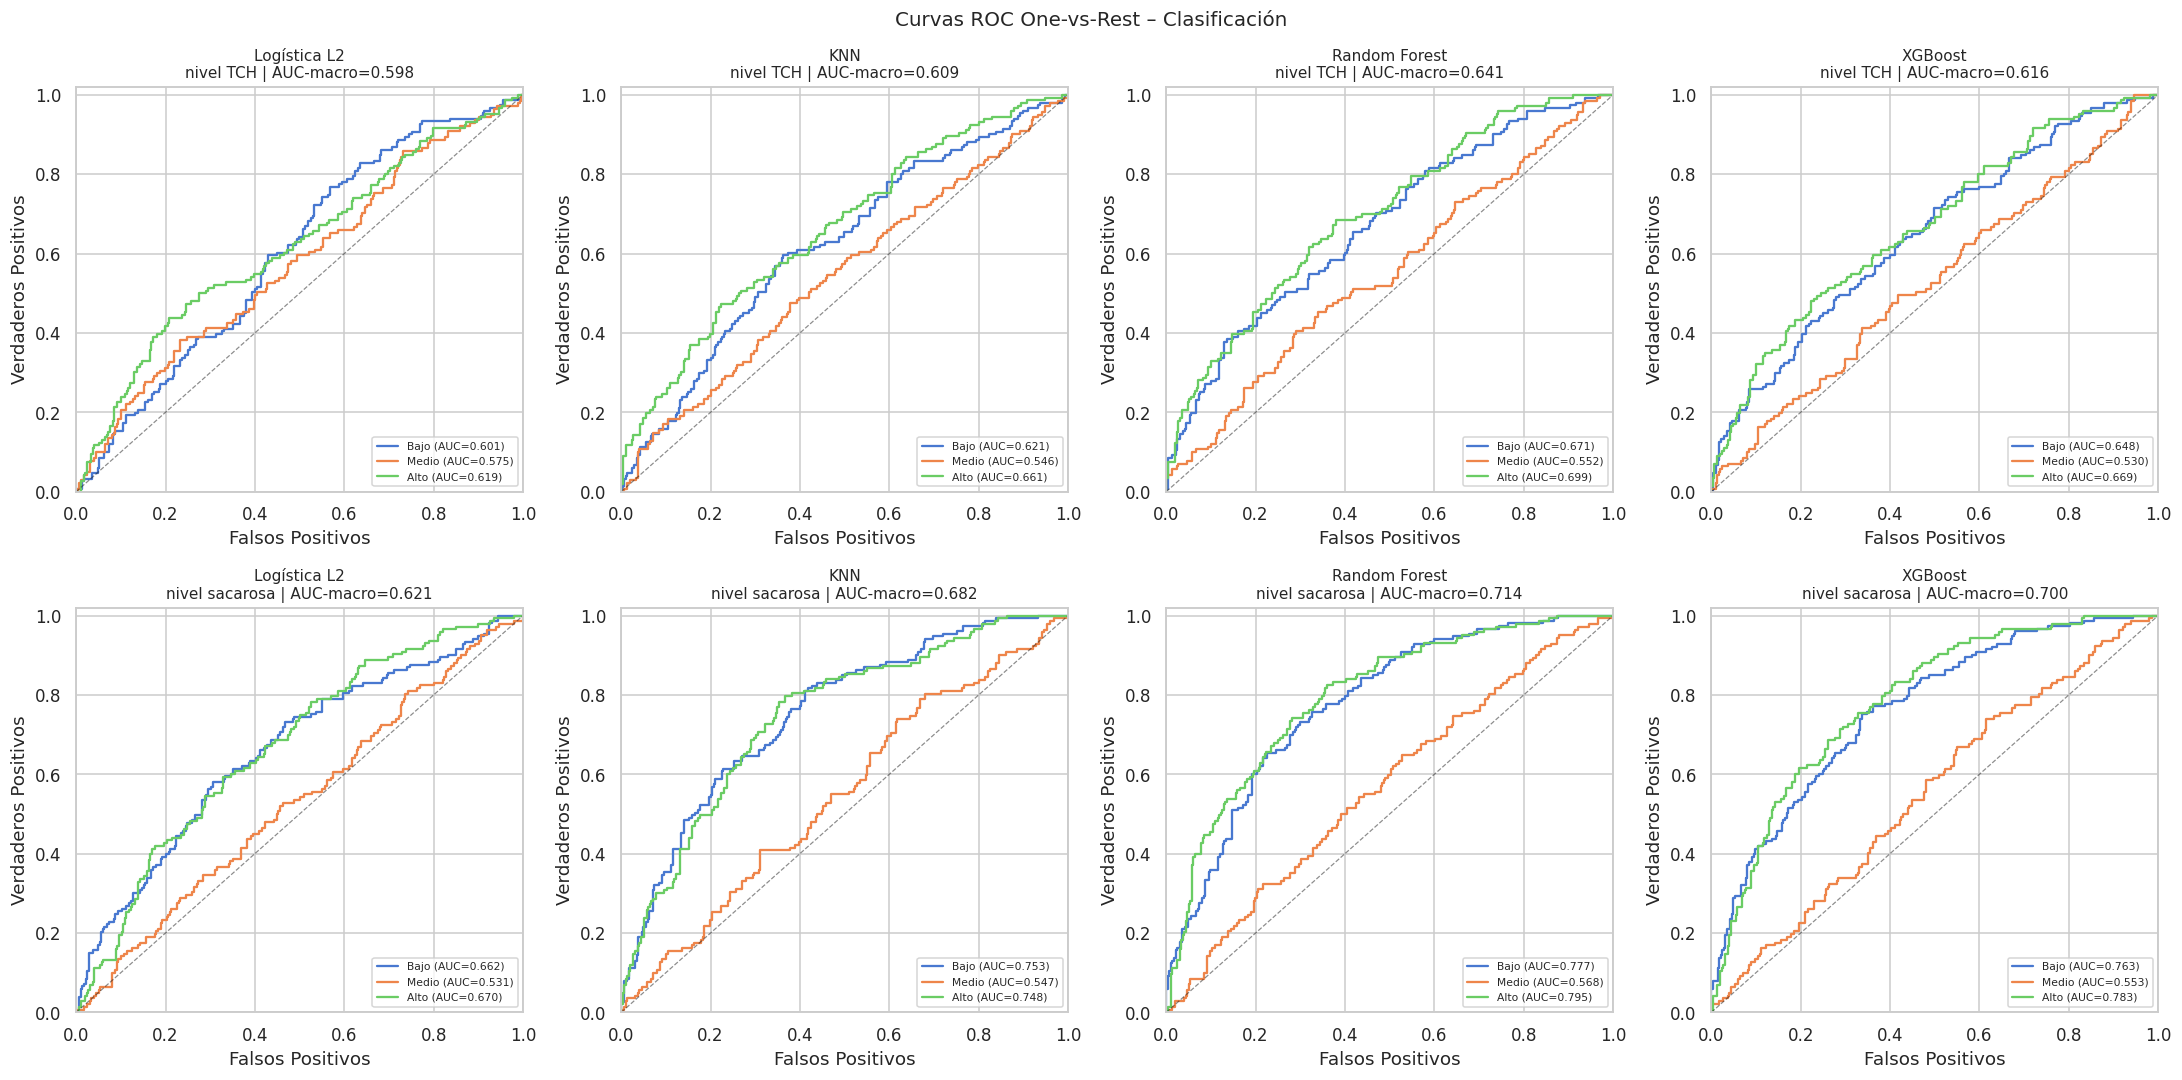


Resumen AUC-macro:
Target         nivel TCH  nivel sacarosa
Modelo                                  
KNN               0.6090          0.6825
Logística L2      0.5984          0.6207
Random Forest     0.6405          0.7136
XGBoost           0.6155          0.6999


In [26]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

auc_resumen = []

for row, target in enumerate(TARGETS_CLF):
    nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
    y_test = splits_clf[target]['y_test']
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

    for col, (nombre_m, resultados) in enumerate(modelos_clf.items()):
        ax = axes[row, col]
        y_proba = resultados[target]['y_proba']

        # ROC por clase + AUC macro
        for i, label in enumerate(LABELS_CLF):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            auc_i = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
            ax.plot(fpr, tpr, linewidth=1.5, label=f'{label} (AUC={auc_i:.3f})')

        auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        auc_resumen.append({
            'Modelo': nombre_m, 'Target': nombre_t, 'AUC-macro': round(auc_macro, 4)
        })

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
        ax.set_xlabel('Falsos Positivos')
        ax.set_ylabel('Verdaderos Positivos')
        ax.set_title(f'{nombre_m}\n{nombre_t} | AUC-macro={auc_macro:.3f}', fontsize=10)
        ax.legend(loc='lower right', fontsize=7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)

plt.suptitle('Curvas ROC One-vs-Rest – Clasificación', fontsize=13)
plt.tight_layout()
plt.show()

print('\nResumen AUC-macro:')
print(pd.DataFrame(auc_resumen).pivot(index='Modelo', columns='Target', values='AUC-macro').to_string())

---
## 17. Learning Curves – Diagnóstico de Overfit / Underfit

Las curvas de aprendizaje muestran cómo evoluciona el error de entrenamiento y validación al aumentar el tamaño del set de entrenamiento. Permiten detectar:
- **Overfit**: gap grande entre train y validación → más datos o regularización
- **Underfit**: ambos errores altos y planos → modelo demasiado simple
- **Bien ajustado**: errores convergen a un valor aceptable

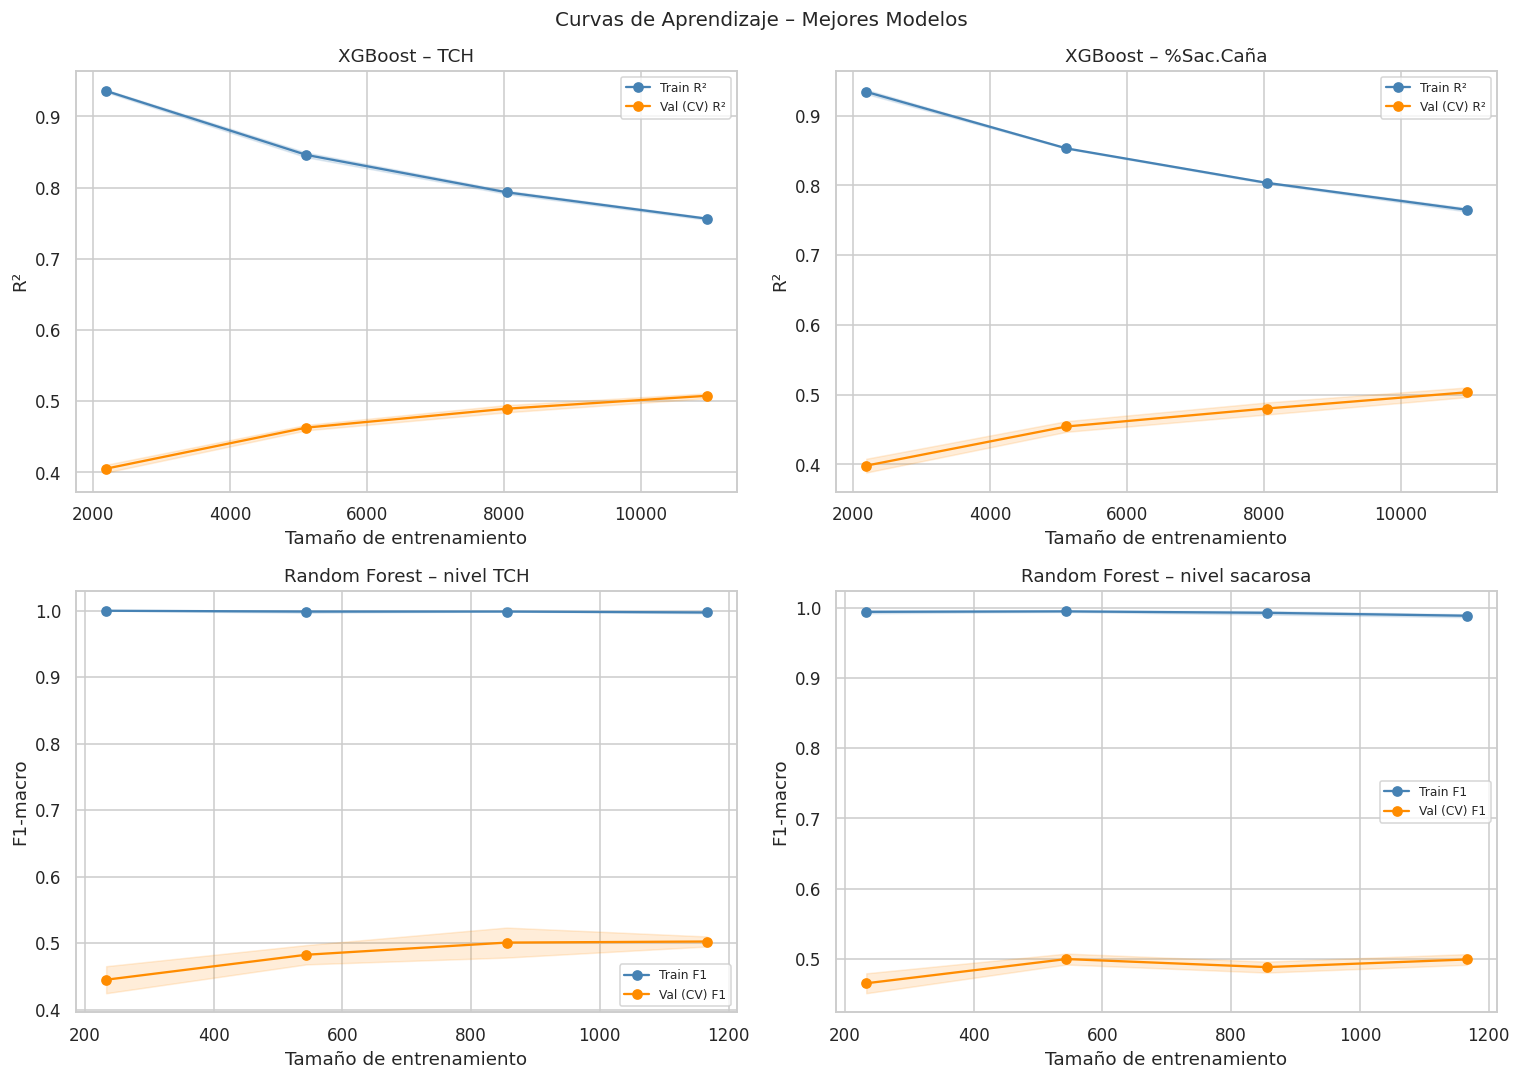

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Aprendizaje – Regresión: mejor modelo (XGBoost) sobre TCH y %Sac.Caña.
# n_jobs=2 y 4 puntos de tamaño para evitar OOM.
for col, target in enumerate(TARGETS_REG):
    ax = axes[0, col]
    pipe = resultados_xgb_reg[target]['modelo']
    sizes, train_scores, val_scores = learning_curve(
        pipe, X_reg_tree_train, Y[target][idx_train],
        train_sizes=np.linspace(0.2, 1.0, 4),
        cv=3, scoring='r2', n_jobs=2, random_state=SEED
    )
    ax.plot(sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train R²')
    ax.fill_between(sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color='steelblue')
    ax.plot(sizes, val_scores.mean(axis=1), 'o-', color='darkorange', label='Val (CV) R²')
    ax.fill_between(sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color='darkorange')
    ax.set_xlabel('Tamaño de entrenamiento')
    ax.set_ylabel('R²')
    ax.set_title(f'XGBoost – {target}')
    ax.legend(fontsize=8)

# Aprendizaje – Clasificación: mejor modelo por target.
mejores_clf = {}
for target in TARGETS_CLF:
    nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
    mejor = tabla_clf[tabla_clf['Target'] == nombre_t].nlargest(1, 'F1-macro').iloc[0]['Modelo']
    if mejor == 'Random Forest':
        mejores_clf[target] = ('Random Forest', resultados_rf_clf[target]['modelo'])
    elif mejor == 'XGBoost':
        mejores_clf[target] = ('XGBoost', resultados_xgb_clf[target]['modelo'])
    elif mejor == 'KNN':
        mejores_clf[target] = ('KNN', resultados_knn[target]['modelo'])
    else:
        mejores_clf[target] = ('Logística L2', resultados_lr[target]['modelo'])

for col, target in enumerate(TARGETS_CLF):
    ax = axes[1, col]
    nombre, pipe = mejores_clf[target]
    s = splits_clf[target]
    X_tr = X_clf_full.iloc[s['train']]
    sizes, train_scores, val_scores = learning_curve(
        pipe, X_tr, s['y_train'],
        train_sizes=np.linspace(0.2, 1.0, 4),
        cv=3, scoring='f1_macro', n_jobs=2, random_state=SEED
    )
    ax.plot(sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train F1')
    ax.fill_between(sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color='steelblue')
    ax.plot(sizes, val_scores.mean(axis=1), 'o-', color='darkorange', label='Val (CV) F1')
    ax.fill_between(sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color='darkorange')
    nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
    ax.set_xlabel('Tamaño de entrenamiento')
    ax.set_ylabel('F1-macro')
    ax.set_title(f'{nombre} – {nombre_t}')
    ax.legend(fontsize=8)

plt.suptitle('Curvas de Aprendizaje – Mejores Modelos', fontsize=13)
plt.tight_layout()
plt.show()


---
## 18. Análisis de Errores – Regresión y Clasificación

Identificamos dónde fallan los mejores modelos para conectar errores con el contexto agronómico.

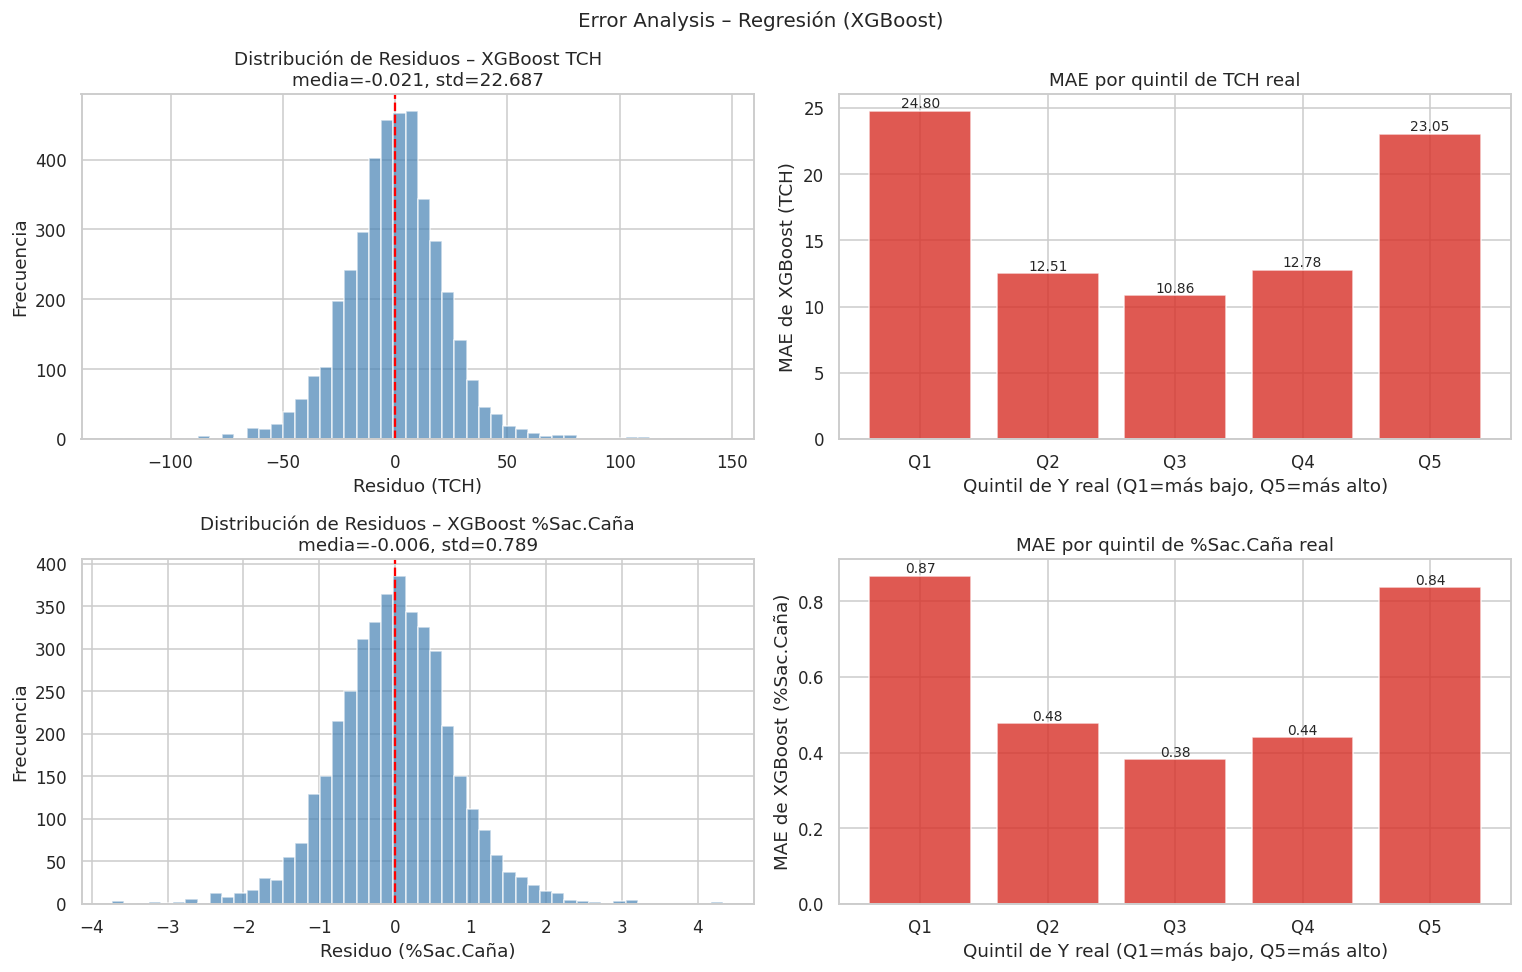


── Casos mal clasificados con MÁS confianza (top errores) ──

nivel TCH – top 5 errores con alta confianza:
 edad  cortes  lluvias  dosismad  Real Predicho  Confianza
 12.4       5      105       1.2 Medio     Bajo   0.833438
 12.9       1      256       1.0 Medio     Alto   0.806760
 13.9       1      206       1.0 Medio     Alto   0.728508
 13.0       4      111       0.8 Medio     Bajo   0.720852
 15.8       1      496       1.4 Medio     Alto   0.719634

nivel sacarosa – top 5 errores con alta confianza:
 edad  cortes  lluvias  dosismad  Real Predicho  Confianza
 12.9       2       99       1.6 Medio     Alto   0.920274
 12.9       2       88       1.2 Medio     Alto   0.794332
 12.5       2      119       0.8 Medio     Alto   0.794279
 14.0       1      444       1.4 Medio     Bajo   0.785787
 12.0       4      282       1.4  Alto     Bajo   0.739873


In [28]:
# Error analysis – Regresión: distribución de residuos por mejor modelo (XGBoost) y por bin de Y real.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, target in enumerate(TARGETS_REG):
    res = resultados_xgb_reg[target]
    y_true, y_pred = res['y_test'], res['y_pred']
    residuos = y_true - y_pred

    # 1) Histograma de errores absolutos
    ax = axes[row, 0]
    ax.hist(residuos, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel(f'Residuo ({target})')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Distribución de Residuos – XGBoost {target}\n'
                 f'media={residuos.mean():.3f}, std={residuos.std():.3f}')

    # 2) Error absoluto medio por cuantil de Y real (¿el modelo falla en extremos?)
    bins = pd.qcut(y_true, q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    df_err = pd.DataFrame({'bin': bins, 'err_abs': np.abs(residuos)})
    err_by_bin = df_err.groupby('bin')['err_abs'].mean()

    ax = axes[row, 1]
    bars = ax.bar(err_by_bin.index.astype(str), err_by_bin.values, color='#d73027', alpha=0.8)
    for bar, v in zip(bars, err_by_bin.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel(f'MAE de XGBoost ({target})')
    ax.set_title(f'MAE por quintil de {target} real')
    ax.set_xlabel('Quintil de Y real (Q1=más bajo, Q5=más alto)')

plt.suptitle('Error Analysis – Regresión (XGBoost)', fontsize=13)
plt.tight_layout()
plt.show()

# Error analysis – Clasificación: mostrar características de los casos más difíciles.
print('\n── Casos mal clasificados con MÁS confianza (top errores) ──')
for target in TARGETS_CLF:
    nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
    res = resultados_rf_clf[target]
    s = splits_clf[target]
    X_test = X_clf_full.iloc[s['test']].copy().reset_index(drop=True)
    y_true = res['y_test']
    y_pred = res['y_pred']
    y_proba = res['y_proba']

    # Confianza en la predicción incorrecta
    confianza_pred = y_proba.max(axis=1)
    err_mask = y_true != y_pred
    if err_mask.sum() == 0:
        continue
    err_df = X_test[err_mask].copy()
    err_df['Real']    = [LABELS_CLF[i] for i in y_true[err_mask]]
    err_df['Predicho'] = [LABELS_CLF[i] for i in y_pred[err_mask]]
    err_df['Confianza'] = confianza_pred[err_mask]
    err_df = err_df.sort_values('Confianza', ascending=False).head(5)

    print(f'\n{nombre_t} – top 5 errores con alta confianza:')
    print(err_df[['edad', 'cortes', 'lluvias', 'dosismad', 'Real', 'Predicho', 'Confianza']].to_string(index=False))

---
## 19. Insights de Negocio para el Ingenio Providencia

Conexión final entre los hallazgos técnicos y la operación del ingenio.

In [29]:
def get_top_features(pipe, n=5):
    feat_names = list(pipe.named_steps['prep'].get_feature_names_out())
    final_step_name = [s for s in pipe.named_steps if s != 'prep'][0]
    imp = pipe.named_steps[final_step_name].feature_importances_
    return pd.Series(imp, index=feat_names).nlargest(n)

print('=' * 70)
print('INSIGHTS DE NEGOCIO – INGENIO PROVIDENCIA')
print('=' * 70)

# Mejor modelo regresión y top variables
print('\n[1] PREDICCIÓN DE TCH (toneladas de caña por hectárea)')
xgb_tch = resultados_xgb_reg["TCH"]
print(f'  Mejor modelo: XGBoost  |  R²={xgb_tch["R2"]:.3f}, RMSE={xgb_tch["RMSE"]:.2f} ton/ha')
print(f'  → Sobre una media de {df_reg["TCH"].mean():.1f} ton/ha, el error típico (~RMSE) es '
      f'≈ {xgb_tch["RMSE"]/df_reg["TCH"].mean()*100:.1f}% de la media.')
print(f'  Top 5 variables que más explican TCH (XGBoost):')
print(get_top_features(xgb_tch["modelo"], 5).to_string())

print('\n[2] PREDICCIÓN DE %Sac.Caña (calidad del azúcar)')
xgb_sac = resultados_xgb_reg["%Sac.Caña"]
print(f'  Mejor modelo: XGBoost  |  R²={xgb_sac["R2"]:.3f}, RMSE={xgb_sac["RMSE"]:.3f} pp')
print(f'  → Error típico de {xgb_sac["RMSE"]:.2f} puntos porcentuales sobre media de '
      f'{df_reg["%Sac.Caña"].mean():.2f}% (≈{xgb_sac["RMSE"]/df_reg["%Sac.Caña"].mean()*100:.1f}%).')
print(f'  Top 5 variables que más explican %Sac.Caña (XGBoost):')
print(get_top_features(xgb_sac["modelo"], 5).to_string())

print('\n[3] CLASIFICACIÓN POR NIVEL DE RENDIMIENTO')
for target in TARGETS_CLF:
    nombre_t = target.replace('_num', '').replace('nivel_', 'nivel ')
    nombre_m, pipe = mejores_clf[target]
    res_dict = {'Random Forest': resultados_rf_clf, 'XGBoost': resultados_xgb_clf,
                'KNN': resultados_knn, 'Logística L2': resultados_lr}[nombre_m][target]
    print(f'\n  {nombre_t}: mejor = {nombre_m}')
    print(f'    Acc={res_dict["Accuracy"]:.3f}, F1={res_dict["F1"]:.3f}, Kappa={res_dict["Kappa"]:.3f}')

print('\n[4] RECOMENDACIONES OPERATIVAS')
print('  a. Maduración: la dosis y semanas de madurante están entre los predictores')
print('     más importantes de %Sac.Caña → estandarizar protocolo por variedad y zona.')
print('  b. Ventana climática: las lluvias de los 2 meses previos a cosecha tienen')
print('     impacto NEGATIVO en %Sac.Caña → planificar cosechas evitando picos pluviales.')
print('  c. Rotación de variedades: existen diferencias de TCH entre variedades de hasta')
print('     20-30 ton/ha → priorizar variedades de alto rendimiento por zona-suelo.')
print('  d. Edad óptima de corte: TCH crece con la edad del cultivo hasta cierto punto')
print('     → usar el modelo para identificar la ventana óptima por lote.')
print('  e. Variables faltantes que mejorarían la predicción:')
print('     • Datos de sensores (NDVI, humedad foliar, satelital).')
print('     • Información de fertilización por dosis y fecha (hoy con >90% nulos).')
print('     • Temperatura/radiación por estación cercana (hoy 78% nulos).')

print('\n[5] LIMITACIONES IDENTIFICADAS')
print('  • R² en regresión ≈ 0.5 indica que aún hay variabilidad no capturada.')
print('  • Accuracy en clasificación ≈ 0.55 sugiere fronteras difusas entre clases medias.')
print('  • BD_IPSA_1940 es un subconjunto de UNA variedad — los modelos no generalizan')
print('    a otras variedades sin reentrenamiento.')
print('  • La consigna usa hold-out aleatorio; en producción se recomienda split temporal')
print('    (entrenar con años pasados, validar con año más reciente).')

print('\n' + '=' * 70)

INSIGHTS DE NEGOCIO – INGENIO PROVIDENCIA

[1] PREDICCIÓN DE TCH (toneladas de caña por hectárea)
  Mejor modelo: XGBoost  |  R²=0.519, RMSE=22.69 ton/ha
  → Sobre una media de 130.0 ton/ha, el error típico (~RMSE) es ≈ 17.5% de la media.
  Top 5 variables que más explican TCH (XGBoost):
cat__Suelo_CERRITO         0.079170
cat__Variedad_CC05-430     0.073242
cat__Variedad_CC85-92      0.061060
cat__Zona_IP02             0.042003
cat__Variedad_CC01-1940    0.038001

[2] PREDICCIÓN DE %Sac.Caña (calidad del azúcar)
  Mejor modelo: XGBoost  |  R²=0.527, RMSE=0.789 pp
  → Error típico de 0.79 puntos porcentuales sobre media de 12.32% (≈6.4%).
  Top 5 variables que más explican %Sac.Caña (XGBoost):
num__Cod. T.Cultivo        0.290968
num__Dosis Madurante       0.059355
cat__Variedad_RB73-2223    0.030387
cat__Variedad_CC05-430     0.028300
cat__Variedad_CC85-92      0.027932

[3] CLASIFICACIÓN POR NIVEL DE RENDIMIENTO

  nivel TCH: mejor = Random Forest
    Acc=0.470, F1=0.468, Kappa=0.205
